# Análise Exploratória dos dados

In [6]:
#Se mão tiver instalado, instale a biblioteca pyarrow
#pip install pyarrow

In [22]:
# Pacotes usados
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.graph_objects as go
from scipy.stats import chi2_contingency
import scipy.stats as stats
from scipy.stats import boxcox
from pathlib import Path
import os
import pyarrow
import matplotlib.pyplot as plt


In [8]:
# Define o caminho base do projeto
# base_dir = Path.cwd()
# dados_path = BASE_DIR / 'dados' / 'enem' / 'microdados_enem_2023' / 'DADOS' / 'MICRODADOS_ENEM_2023.csv'

In [9]:
# print(base_dir)

In [10]:
## Carregamento dos dados
df_enem_2023 = pd.read_parquet('G:\Meu Drive\ciencia de dados\Pos\TCC\TCC\df_enem_2023.parquet')
presentes_df_enem_2023 = pd.read_parquet('G:\Meu Drive\ciencia de dados\Pos\TCC\TCC\presentes_df_enem_2023.parquet')
top_20 = pd.read_parquet('G:\\Meu Drive\\ciencia de dados\\Pos\\TCC\\TCC\\top_20.parquet')

<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:3: SyntaxWarning: invalid escape sequence '\M'
<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:3: SyntaxWarning: invalid escape sequence '\M'
C:\Users\prisc\AppData\Local\Temp\ipykernel_26068\3833618401.py:2: SyntaxWarning: invalid escape sequence '\M'
  df_enem_2023 = pd.read_parquet('G:\Meu Drive\ciencia de dados\Pos\TCC\TCC\df_enem_2023.parquet')
C:\Users\prisc\AppData\Local\Temp\ipykernel_26068\3833618401.py:3: SyntaxWarning: invalid escape sequence '\M'
  presentes_df_enem_2023 = pd.read_parquet('G:\Meu Drive\ciencia de dados\Pos\TCC\TCC\presentes_df_enem_2023.parquet')


In [11]:
top_20.columns

Index(['INSCRICAO', 'FAIXA_ETARIA', 'SEXO', 'ESTADO_CIVIL', 'COR',
       'NACIONALIDADE', 'ST_CONCLUSAO', 'ANO_CONCLUSAO', 'MUNICIPIO', 'UF',
       'ADM_ESC', 'TP_URBANA_RURAL', 'TP_PRESENCA_CH', 'TP_PRESENCA_MT',
       'NOTA_CN', 'NOTA_CH', 'NOTA_LC', 'NOTA_MT', 'NOTA_COMP1_REDACAO',
       'NOTA_COMP2_REDACAO', 'NOTA_COMP3_REDACAO', 'NOTA_COMP4_REDACAO',
       'NOTA_COMP5_REDACAO', 'NOTA_REDACAO', 'ESCOLARIDADE_PATERNA',
       'ESCOLARIDADE_MATERNA', 'RENDA_FAMILIAR', 'POSSUI_DIARISTA',
       'QTD_BANHEIROS', 'QTD_CARROS', 'QTD_GELADEIRA', 'QTD_TV_COLORIDA',
       'QTD_COMPUTADOR', 'ACESSO_INTERNET', 'REGIAO', 'MEDIA', 'IS_TOP20'],
      dtype='object')

## Estrutura do dataframe

In [12]:
df_enem_2023.head()

,INSCRICAO,FAIXA_ETARIA,SEXO,ESTADO_CIVIL,COR,NACIONALIDADE,ST_CONCLUSAO,ANO_CONCLUSAO,MUNICIPIO,UF,...,POSSUI_DIARISTA,QTD_BANHEIROS,QTD_CARROS,QTD_GELADEIRA,QTD_TV_COLORIDA,QTD_COMPUTADOR,ACESSO_INTERNET,REGIAO,MEDIA,IS_TOP20
0,210059085136,41_45,Masculino,Casado_Mora_com_companheiro,Branca,Brasileiro,Ja_conclui_Ensino_Medio,17,Desconhecido,Desconhecido,...,3_a_4_vezes_semanais,2,2,2,1,nao,sim,Desconhecido,NaN,0
1,210059527735,31_35,Masculino,Casado_Mora_com_companheiro,Branca,Nao_informado,Ja_conclui_Ensino_Medio,16,Desconhecido,Desconhecido,...,nao,1,2,1,1,3,sim,Desconhecido,NaN,0
2,210061103945,21,Feminino,Solteiro(a),Branca,Brasileiro,Ja_conclui_Ensino_Medio,0,Desconhecido,Desconhecido,...,nao,1,1,1,1,nao,sim,Desconhecido,507.94,0
3,210060214087,17,Feminino,Solteiro(a),Parda,Brasileiro,Estou_cursando_concluirei_Ensino_Medio_em_2023,0,Fortaleza,CE,...,nao,1,nao,1,1,nao,sim,Nordeste,564.28,0
4,210059980948,18,Feminino,Solteiro(a),Parda,Brasileiro,Estou_cursando_concluirei_Ensino_Medio_em_2023,0,Quixadá,CE,...,nao,1,nao,1,1,nao,nao,Nordeste,425.38,0


## Análise dos dados pessoais

In [13]:
#Dados categóricos
categoricas=['FAIXA_ETARIA', 'SEXO', 'ESTADO_CIVIL', 'COR',
       'NACIONALIDADE', 'ST_CONCLUSAO', 'ANO_CONCLUSAO', 'UF',
       'ADM_ESC', 'TP_URBANA_RURAL','ESCOLARIDADE_PATERNA',
       'ESCOLARIDADE_MATERNA', 'RENDA_FAMILIAR', 'REGIAO']

Criação dos dataframe, e dos arquivos csv, contendo o total e a porcentagem do total, dos candidatos inscritos, dos candidatos presentes na prova de matemática e dos candidatos dentre os top_20, de cada categoria.

In [14]:
for cat in categoricas:
    df_cat=pd.DataFrame([df_enem_2023[cat].value_counts(dropna=False),df_enem_2023[cat].value_counts(dropna=False, normalize=True)*100,
                  presentes_df_enem_2023[cat].value_counts(dropna=False),presentes_df_enem_2023[cat].value_counts(dropna=False, normalize=True)*100,
                  top_20[cat].value_counts(dropna=False),top_20[cat].value_counts(dropna=False, normalize=True)*100]).T.sort_values(by=cat)
    #df_cat.to_excel(f'df_{cat}.xlsx', sheet_name=cat) #Usado para criar o arquivo csv
    print(df_cat)


                 count  proportion     count  proportion     count  proportion
FAIXA_ETARIA                                                                  
17            497159.0   15.002287  406881.0   18.777595   95963.0   22.073044
18            878894.0   26.521536  664085.0   30.647583  131267.0   30.193536
19            426390.0   12.866760  288931.0   13.334192   58709.0   13.504021
20            266041.0    8.028063  168604.0    7.781090   35705.0    8.212728
21            182869.0    5.518261  108482.0    5.006454   23375.0    5.376629
22            137534.0    4.150231   77653.0    3.583693   16400.0    3.772266
23            111569.0    3.366710   59628.0    2.751838   12304.0    2.830119
24             91174.0    2.751270   46613.0    2.151194    8995.0    2.068996
25             72968.0    2.201885   36046.0    1.663526    6798.0    1.563650
26_30         245671.0    7.413377  114191.0    5.269925   19981.0    4.595954
31_35         133003.0    4.013503   60070.0    2.77

In [15]:
df_freq=pd.DataFrame([df_enem_2023['ANO_CONCLUSAO'].value_counts(dropna=False),df_enem_2023['ANO_CONCLUSAO'].value_counts(dropna=False, normalize=True)]).T
df_freq

,count,proportion
ANO_CONCLUSAO,,
0,1623067.0,0.489777
1,418530.0,0.126296
2,264183.0,0.079720
17,167321.0,0.050491
3,149798.0,0.045203
4,136449.0,0.041175
5,104195.0,0.031442
6,85411.0,0.025774
7,65549.0,0.019780


In [16]:
# Soma acumulada da quantidade de candidatos que terminaram a cada ano
df_enem_2023['ANO_CONCLUSAO'].value_counts(dropna=False, normalize=True, sort='ANO_CONCLUSAO').cumsum()

ANO_CONCLUSAO
0     0.489777
1     0.616073
2     0.695793
17    0.746284
3     0.791487
4     0.832662
5     0.864104
6     0.889877
7     0.909657
8     0.926185
9     0.940263
10    0.952309
11    0.963025
12    0.971777
13    0.980051
14    0.987486
15    0.993823
16    1.000000
Name: proportion, dtype: float64

### Gráficos

In [17]:
for cat in categoricas:
  label_presentes=presentes_df_enem_2023[cat]
  label_top20=top_20[cat]

  fig = go.Figure(data=[
      go.Bar(
          name='Candidatos Presentes',
          x=label_presentes.value_counts().index,
          y=label_presentes.value_counts(dropna=False, normalize=True).values,
          text=label_presentes.value_counts().values.round(3),  # Valores exibidos
          textposition='outside'  # Posição acima das barras
      ),
      go.Bar(
          name='Candidatos Destaque em Matemática',
          x=label_top20.value_counts().index,
          y=label_top20.value_counts(dropna=False, normalize=True).values,
          text=label_top20.value_counts().values.round(3),  # Valores exibidos
          textposition='outside'  # Posição acima das barras
      )
  ])

  # Ajustando layout
  fig.update_layout(
      barmode='group',
      title_text=f'Proporção de Candidatos por {cat}'
  )

  fig.show()

### Tabelas de Contingencia

A tabela de contingecia mostra a distribuição entre duas variáveis categóricas.

A tabela a seguir, por exemplo, mostra que é uma tabela de contingência com os dados normalizados. 
Observe pela tabela que dos candidatos que tinham 17 anos, 80,67% não estavam entre os top20 e 19,32% estão entre os top 20.

Mostra a proporção de cada categoria que está no top 20.



In [18]:
for cat in categoricas:
    tabela = pd.crosstab(df_enem_2023[cat], df_enem_2023['IS_TOP20'], normalize='index')
    display(tabela)

IS_TOP20,0,1
FAIXA_ETARIA,,
17,0.806784,0.193216
18,0.850489,0.149511
19,0.862173,0.137827
20,0.865671,0.134329
21,0.872072,0.127928
22,0.880633,0.119367
23,0.889611,0.110389
24,0.901178,0.098822
25,0.906767,0.093233


IS_TOP20,0,1
SEXO,,
Feminino,0.897347,0.102653
Masculino,0.824639,0.175361


IS_TOP20,0,1
ESTADO_CIVIL,,
Casado_Mora_com_companheiro,0.938834,0.061166
Divorciado_Desquitado_Separado,0.935762,0.064238
Nao_informado,0.911146,0.088854
Solteiro(a),0.860201,0.139799
Viuvo,0.973813,0.026187


IS_TOP20,0,1
COR,,
Amarela,0.859611,0.140389
Branca,0.787828,0.212172
Indígena,0.968619,0.031381
Nao_declarado,0.865773,0.134227
Parda,0.914651,0.085349
Preta,0.940705,0.059295


IS_TOP20,0,1
NACIONALIDADE,,
Brasileiro,0.867085,0.132915
Brasileiro_Nato_nascido_no_exterior,0.758920,0.241080
Brasileiro_Naturalizado,0.959071,0.040929
Estrangeiro,0.890671,0.109329
Nao_informado,0.938144,0.061856


...

IS_TOP20,0,1
TP_URBANA_RURAL,,
rural,0.918541,0.081459
urbana,0.816554,0.183446
Desconhecido,0.888343,0.111657


IS_TOP20,0,1
ESCOLARIDADE_PATERNA,,
4ano_incompleto,0.952835,0.047165
9ano_incompleto,0.919896,0.080104
ensino_medio_completo,0.843402,0.156598
ensino_medio_incompleto,0.900213,0.099787
ensino_superior,0.646163,0.353837
nao_sabe_responder,0.936442,0.063558
pos_graducao_completa,0.565551,0.434449
sem_escoladidade,0.975183,0.024817


IS_TOP20,0,1
ESCOLARIDADE_MATERNA,,
4ano_incompleto,0.964753,0.035247
9ano_incompleto,0.942003,0.057997
ensino_medio_completo,0.872384,0.127616
ensino_medio_incompleto,0.927514,0.072486
ensino_superior,0.707424,0.292576
nao_sabe_responder,0.947843,0.052157
pos_graducao_completa,0.648288,0.351712
sem_escoladidade,0.982359,0.017641


IS_TOP20,0,1
RENDA_FAMILIAR,,
nenhuma_renda,0.974457,0.025543
renda_10560_11880,0.534718,0.465282
renda_11880_13200,0.507678,0.492322
renda_13200_15840,0.486992,0.513008
renda_1320_1980,0.925153,0.074847
renda_15840_19800,0.457130,0.542870
renda_19800_26400,0.420814,0.579186
renda_1980_2640,0.890175,0.109825
renda_2640_3300,0.847762,0.152238


IS_TOP20,0,1
REGIAO,,
Centro_Oeste,0.838575,0.161425
Nordeste,0.866543,0.133457
Norte,0.913522,0.086478
Sudeste,0.760398,0.239602
Sul,0.787379,0.212621
Desconhecido,0.888343,0.111657


### Correlação entre cada variável pessoal e a probabilidade de estar entre os top20

Para verificar se existe alguma correlação estatisticamente significante entre duas variáveis categóricas, foi usada uma técnica estatística chamada Qui-Quadrado aplicado a uma tabela de contingencia.

Após cosntruir a tabela de contingência, calcula-se as Frequências Esperadas (E).

Se as variáveis fossem independentes, qual seria a contagem esperada em cada célula?

$$E_{ij}=\frac{\text{Total da linha i}\times\text{Total da coluna j}}{\text{Total Geral}}$$

In [19]:
pd.crosstab(df_enem_2023['SEXO'], df_enem_2023['IS_TOP20'])

IS_TOP20,0,1
SEXO,,
Feminino,1801093,206039
Masculino,1077602,229154


Por exemplo, a frequencia esperada de ser homem e estar entre os top20 é dada por:

* Total da linha=1077602+229154=1306756
* Total da coluna= 206039+229154=435193
* Total geral=1801093+206039+206039+229154=2442325

$$E_{2,2}=\frac{1306756 \times 435193}{2442325}=232848$$

O Qui-quadrado ($\chi ^2$) é a comparação entre as frequencias observadas com as frequencias esperadas.

$$\chi ^2 = \sum \frac{(O-E)^2}{E}$$

Nesse caso da tabea de contingência da variável sexo e is_top20, calcula-se a esperança de cada dado da tabela e usa-se a fórmula acima, obtendo $\chi ^2 = 36676$.

Em seguida, encontra-se o valor crítico na tabela de $\chi ^2$ para o grau de liberdade da tabela $(gl=(\text{nº de linhas -1}\times \text{nº de colunas -1}))$

Para $gl=1$ e nível de significancia $\alpha 0,05$ o valor crítico é $3.841$.

Se $\chi ^2$ calculado $> \chi ^2$ crítico → Rejeita H₀, isto significa que há relação entre as variáveis.

Nesse exemplo, como $36676>3,841$ então há relação entre as variáveis.

In [20]:
dict_variaveis_impacto={'Possuem impacto na probabilidade de estar entre os TOP20':[], 'Não há evidencia de relação entre estar em TOP20':[] }

for cat in categoricas:
    contingencia = pd.crosstab(df_enem_2023[cat], df_enem_2023['IS_TOP20'])
    chi2, p, dof, expected = chi2_contingency(contingencia)
    if p<0.05:
        dict_variaveis_impacto['Possuem impacto na probabilidade de estar entre os TOP20'].append(cat)
        print(f"A variável {cat} possui impacto na probabilidade de estar entre os TOP20, com p-valor: {p:.4f} e qui-quadrado: {chi2}")
    else:
        dict_variaveis_impacto['Não há evidencia de relação entre estar em TOP20'].append(cat)
        
print('--'*80)
print(dict_variaveis_impacto)

A variável FAIXA_ETARIA possui impacto na probabilidade de estar entre os TOP20, com p-valor: 0.0000 e qui-quadrado: 49191.90008607814
A variável SEXO possui impacto na probabilidade de estar entre os TOP20, com p-valor: 0.0000 e qui-quadrado: 36676.000784296135
A variável ESTADO_CIVIL possui impacto na probabilidade de estar entre os TOP20, com p-valor: 0.0000 e qui-quadrado: 15526.484881324783
A variável COR possui impacto na probabilidade de estar entre os TOP20, com p-valor: 0.0000 e qui-quadrado: 122493.38797458699
A variável NACIONALIDADE possui impacto na probabilidade de estar entre os TOP20, com p-valor: 0.0000 e qui-quadrado: 5247.798499135113
A variável ST_CONCLUSAO possui impacto na probabilidade de estar entre os TOP20, com p-valor: 0.0000 e qui-quadrado: 3894.12222212443
A variável ANO_CONCLUSAO possui impacto na probabilidade de estar entre os TOP20, com p-valor: 0.0000 e qui-quadrado: 13256.188336915355
A variável UF possui impacto na probabilidade de estar entre os TOP

## Análise das notas

### Distribuição das notas de matemática

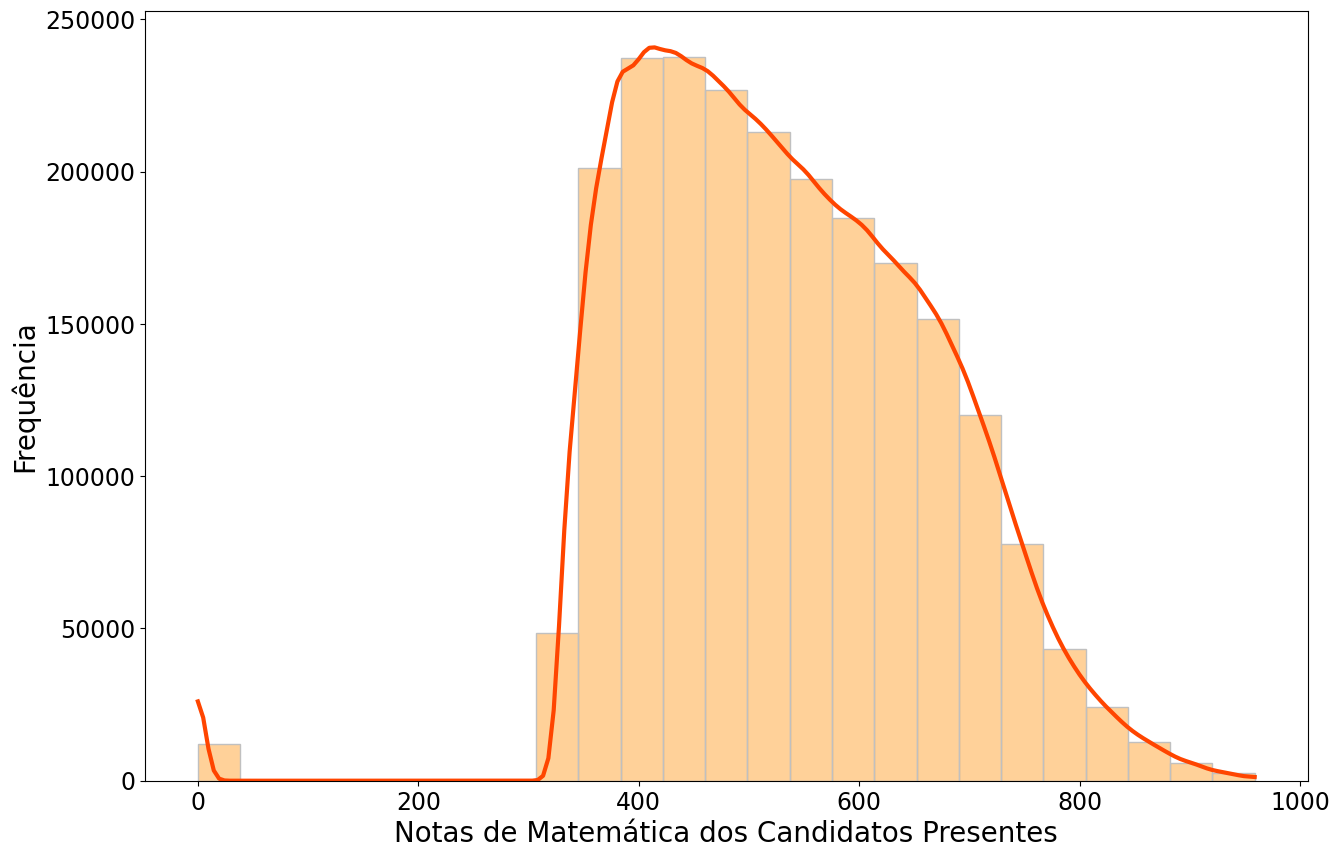

In [23]:
plt.figure(figsize=(15,10))
hist1 = sns.histplot(data=presentes_df_enem_2023['NOTA_MT'], kde=True, bins=25,
                     color = 'darkorange', alpha=0.4, edgecolor='silver',
                     line_kws={'linewidth': 3})
hist1.get_lines()[0].set_color('orangered')
plt.xlabel('Notas de Matemática dos Candidatos Presentes', fontsize=20)
plt.ylabel('Frequência', fontsize=20)
plt.xticks(fontsize=17)
plt.yticks(fontsize=17)
plt.show()

O teste de Kolmogorov-Smirnov compara a  distribuição de frequência acumulada de um conjunto com uma distribuição teórica esperada, neste caso, a distribuição normal.

Esse teste pode ser usado quando são conhecidas a média e o desvio padrão e é indicado para quantidades grande de observações.

As hipóteses do teste de Kolmogorov-Smirnov neste caso são:

    H0: As notas de matemática seguem uma distribuição normal.
    H1: As notas de matemática não seguem uma distribuição normal.

Considerando o nível de significância de 5%.

Se p-valor for maior que 0,05, não rejeitaremos a H0, isto é, as notas de matemática seguem uma distribuição normal.

Ver mais em "Manual de análise de dados" (p. 227)

In [24]:
stat, p_value_ks = stats.kstest(presentes_df_enem_2023['NOTA_MT'], 'norm', args=(presentes_df_enem_2023['NOTA_MT'].mean(), presentes_df_enem_2023['NOTA_MT'].std()))

alpha = 0.05
if p_value_ks > alpha:
    print(f"p-valor é {p_value_ks}>{alpha} e, portanto, não há evidências para rejeitar a normalidade das notas de matemática.")
else:
    print(f"p-valor é {p_value_ks}<{alpha} e, portanto, as notas de matemática não seguem uma distribuição normal.")

p-valor é 0.0<0.05 e, portanto, as notas de matemática não seguem uma distribuição normal.


### Distribuição após Box-Cox e transformação logarítmica

Para utilizar um algoritmo de regressão, é necessário que a variável dependente seja aderente a distribuição normal.

Assim faremos a transformação de Box-Cox com o intuito de transformar essa variável aderente a distribuição normal. Caso essa distibuição não ocorra, faremos a transformação logaritmica.

Se, apesar de todas as transformações, a distribuição não se tornar aderente a normalidade, descartaremos a ppossibilidade de usar modelos de regressão.

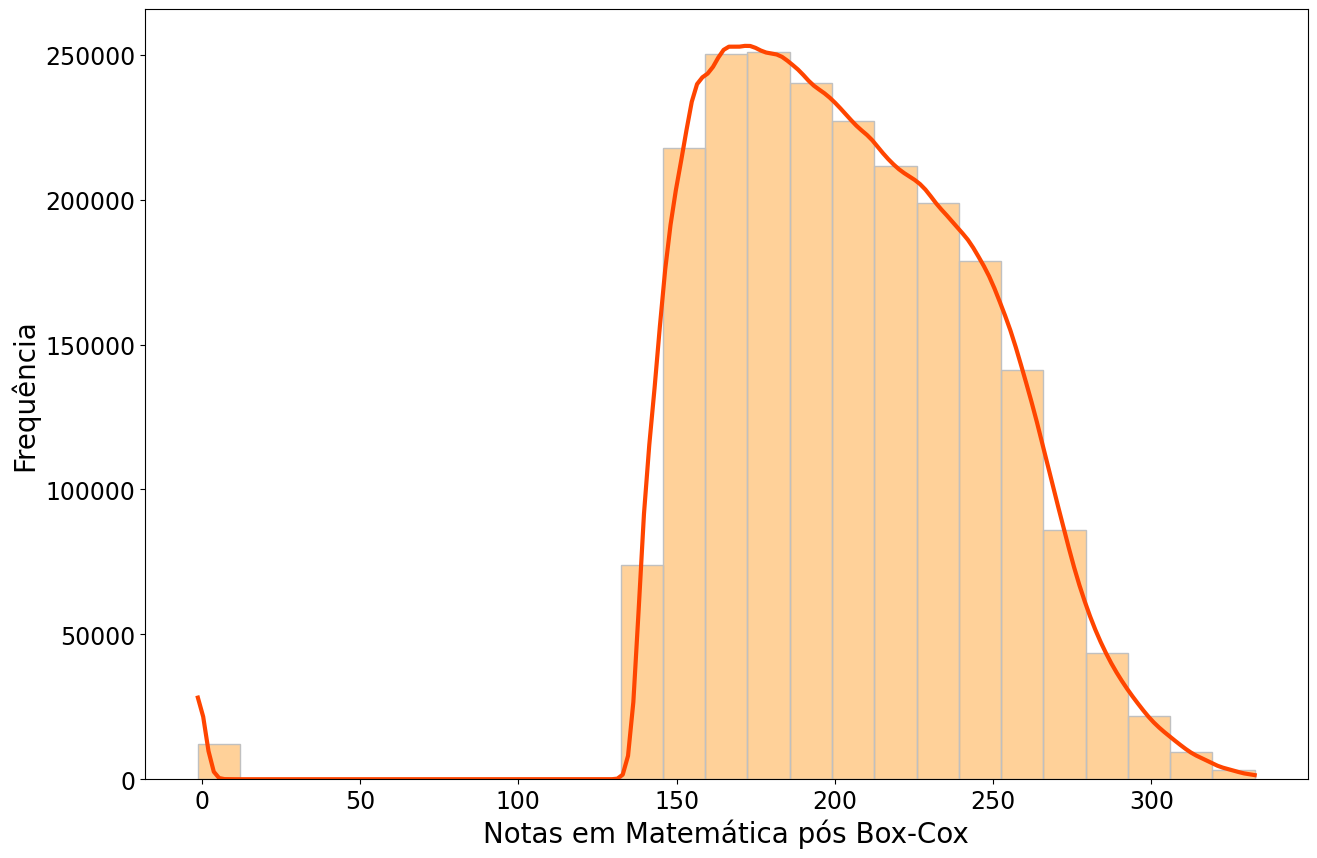

p-valor é 0.0<0.05 e, portanto, os dados não seguem uma distribuição normal.


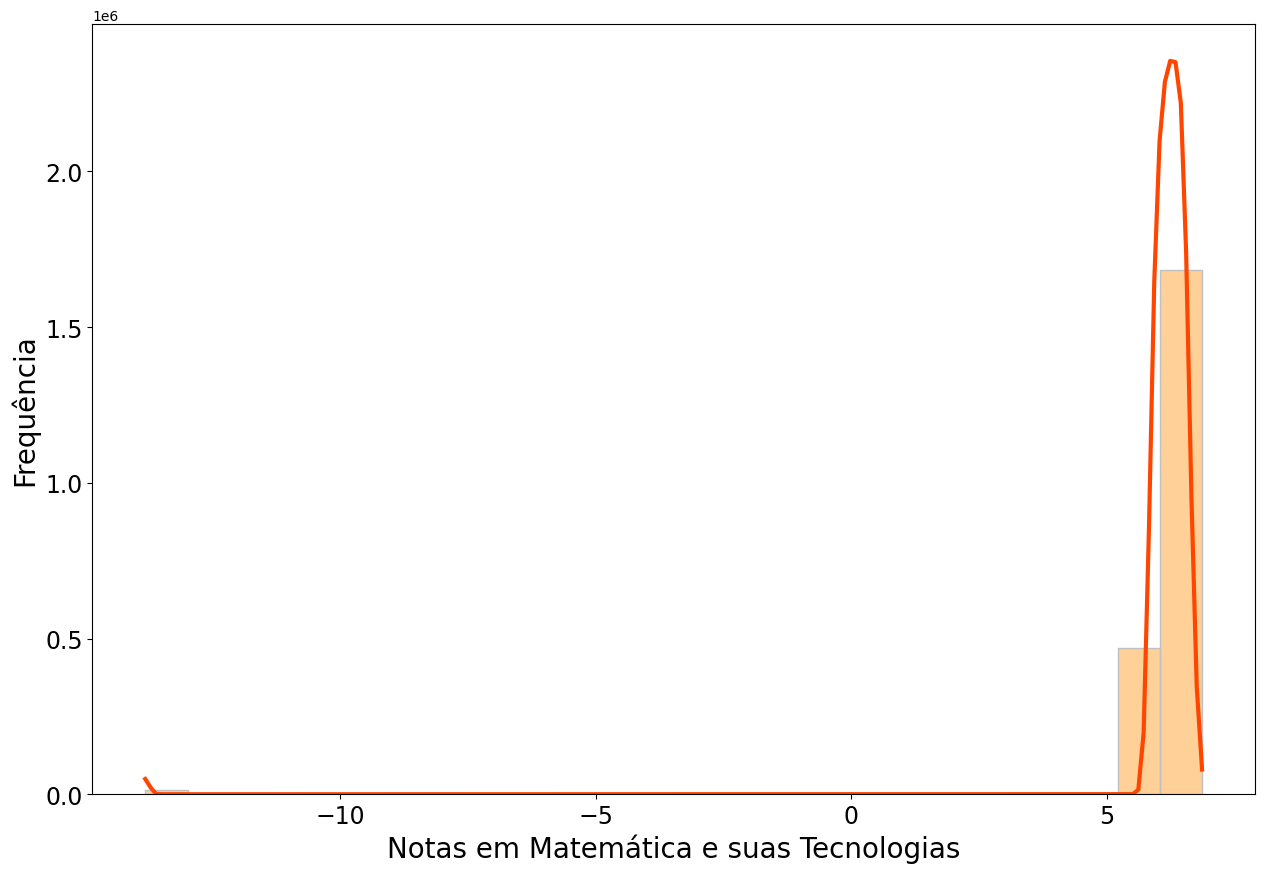

Visto que de nenhuma das tentativas resultou em distribuição de notas aderentes a curva normal, fica descartada a possibilidade de usar algoritmos de regressão.


In [25]:
if p_value_ks<0.05:

    # Transformação das notas zero em um número muito pequeno para conseguir usar o método
    epsilon = 1e-6  # Pequeno deslocamento
    nota_mt_corrigida = presentes_df_enem_2023['NOTA_MT'] + epsilon


    # 'yast' é uma variável que traz os valores transformados (Y*)
    # 'lmbda' é o lambda de Box-Cox
    yast_bc, lmbda_bc = boxcox(nota_mt_corrigida)

    #Gráfico da distribuição de frequência
    plt.figure(figsize=(15,10))
    hist1 = sns.histplot(data=yast_bc, kde=True, bins=25,
                        color = 'darkorange', alpha=0.4, edgecolor='silver',
                        line_kws={'linewidth': 3})
    hist1.get_lines()[0].set_color('orangered')
    plt.xlabel('Notas em Matemática pós Box-Cox', fontsize=20)
    plt.ylabel('Frequência', fontsize=20)
    plt.xticks(fontsize=17)
    plt.yticks(fontsize=17)
    plt.show()

    # Analisa de as notas de matemática, após Box_cox, são aderentes a distribuição normal
    stat_bc, p_value_bc = stats.kstest(yast_bc, 'norm', args=(yast_bc.mean(), yast_bc.std()))

    if p_value_bc > alpha:
        print(f"p-valor é {p_value_bc}>{alpha} e, portanto, a notas após transformação de box-cox segue uma distribuição normal.")
    else:
        print(f"p-valor é {p_value_bc}<{alpha} e, portanto, os dados não seguem uma distribuição normal.")
        
        #Aplicando a transformação logaritmica
        # Analisa de as notas de matemática, após Box_cox, são aderentes a distribuição normal
        nota_mt_corrigida_log=np.log(nota_mt_corrigida)
        stat_log, p_value_log = stats.kstest(nota_mt_corrigida_log, 'norm', args=(nota_mt_corrigida_log.mean(), nota_mt_corrigida_log.std()))


        #Grafico de distribuição de frequencia após transformção log 
        plt.figure(figsize=(15,10))
        hist1 = sns.histplot(data= np.log(nota_mt_corrigida), kde=True, bins=25,
                            color = 'darkorange', alpha=0.4, edgecolor='silver',
                            line_kws={'linewidth': 3})
        hist1.get_lines()[0].set_color('orangered')
        plt.xlabel('Notas em Matemática e suas Tecnologias', fontsize=20)
        plt.ylabel('Frequência', fontsize=20)
        plt.xticks(fontsize=17)
        plt.yticks(fontsize=17)
        plt.show()

        if p_value_log<alpha:
            print('Visto que de nenhuma das tentativas resultou em distribuição de notas aderentes a curva normal, fica descartada a possibilidade de usar algoritmos de regressão.')
        else:
            print('A distribuição das notas, após transformação logaritmica, é aderente a distribuição normal.')
        


### Box-Plots

In [26]:
colunas_notas=['NOTA_CN', 'NOTA_CH', 'NOTA_LC', 'NOTA_MT', 'NOTA_REDACAO']
colunas_notas_redacao=[ 'NOTA_COMP1_REDACAO','NOTA_COMP2_REDACAO', 'NOTA_COMP3_REDACAO', 'NOTA_COMP4_REDACAO','NOTA_COMP5_REDACAO']
notas_presentes_df_enem_2023=presentes_df_enem_2023[colunas_notas]
notas_redacao_presentes_df_enem_2023=presentes_df_enem_2023[colunas_notas_redacao]
notas_redacao_top20_df_enem_2023=top_20[colunas_notas_redacao]

#### Box-Plot das notas objetivas dos candidatos presentes.

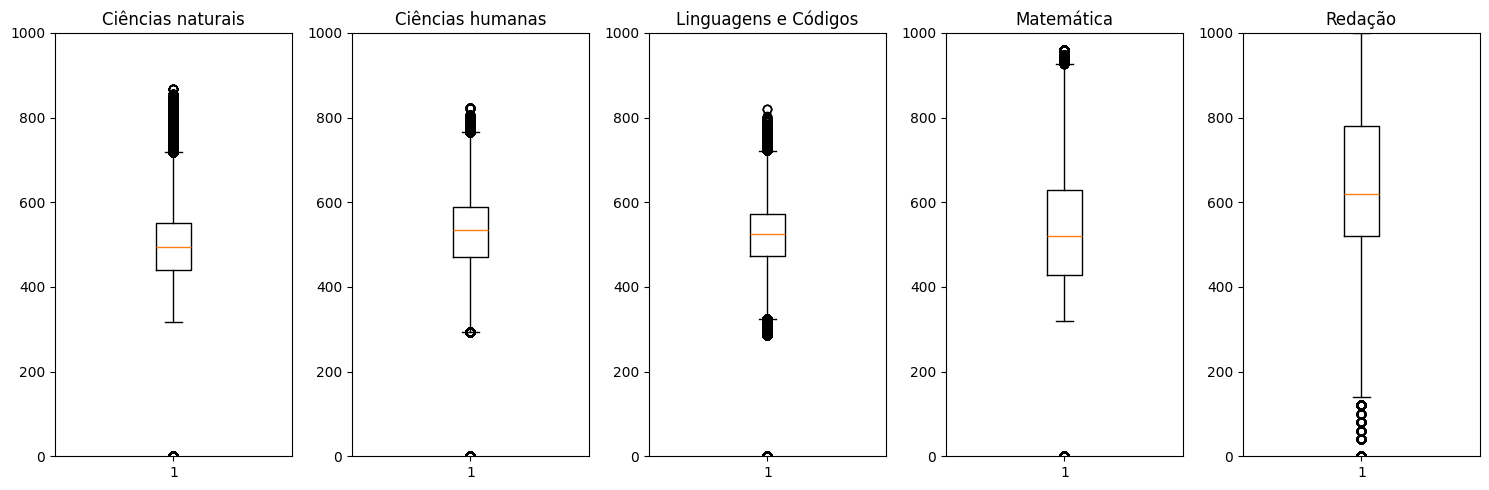

In [27]:
# Criar a figura e os subplots
fig, axes = plt.subplots(1, len(colunas_notas), figsize=(15, 5))
nomes_display={'NOTA_CN': 'Ciências naturais', 'NOTA_CH':'Ciências humanas', 'NOTA_LC': 'Linguagens e Códigos', 'NOTA_MT':'Matemática', 'NOTA_REDACAO':'Redação'}
# Gerar um boxplot para cada coluna
for i, coluna in enumerate(notas_presentes_df_enem_2023.columns):
    # Usando matplotlib
    axes[i].boxplot(notas_presentes_df_enem_2023[coluna])
    titulo = nomes_display.get(coluna, coluna)
    axes[i].set_title(titulo)
    axes[i].set_ylim(0, 1000)

plt.tight_layout()  # Ajusta o espaçamento entre os gráficos
plt.show()


#### Box-plot das notas objetivas dos candidatos top20.

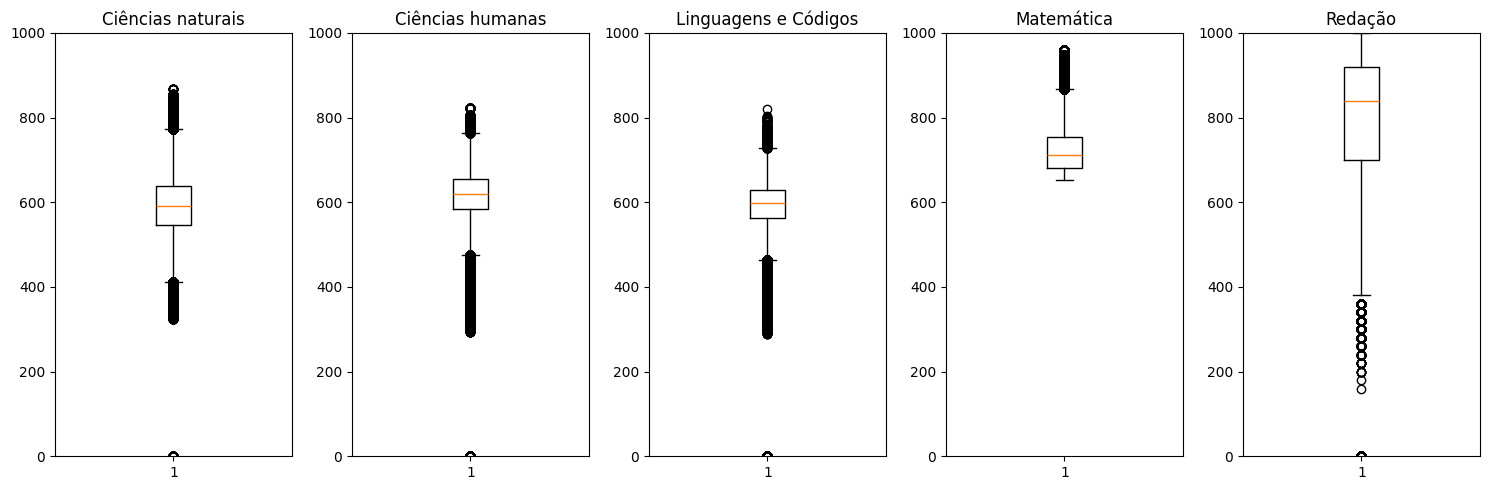

In [28]:
notas_top20_df_enem_2023=top_20[colunas_notas]
notas_redacao_top20_df_enem_2023=top_20[colunas_notas_redacao]

# Criar a figura e os subplots
fig, axes = plt.subplots(1, len(colunas_notas), figsize=(15, 5))
nomes_display={'NOTA_CN': 'Ciências naturais', 'NOTA_CH':'Ciências humanas', 'NOTA_LC': 'Linguagens e Códigos', 'NOTA_MT':'Matemática', 'NOTA_REDACAO':'Redação'}
# Gerar um boxplot para cada coluna
for i, coluna in enumerate(notas_top20_df_enem_2023.columns):
    # Usando matplotlib
    axes[i].boxplot(notas_top20_df_enem_2023[coluna])
    titulo = nomes_display.get(coluna, coluna)
    axes[i].set_title(titulo)
    axes[i].set_ylim(0, 1000)

plt.tight_layout()  # Ajusta o espaçamento entre os gráficos
plt.show()


#### Correlação entre as notas da prova objetiva

In [29]:
# Correlação entre as notas dos candidatos presentes
correlacao_notas_presentes=presentes_df_enem_2023[colunas_notas].corr()
correlacao_notas_presentes

,NOTA_CN,NOTA_CH,NOTA_LC,NOTA_MT,NOTA_REDACAO
NOTA_CN,1.000000,0.615178,0.599665,0.720745,0.449901
NOTA_CH,0.615178,1.000000,0.765228,0.638280,0.492324
NOTA_LC,0.599665,0.765228,1.000000,0.629340,0.498577
NOTA_MT,0.720745,0.638280,0.629340,1.000000,0.515892
NOTA_REDACAO,0.449901,0.492324,0.498577,0.515892,1.000000


In [30]:
# Correlação entre as notas dos candidatos TOP20
correlacao_notas_top20=top_20[colunas_notas].corr()
correlacao_notas_top20

,NOTA_CN,NOTA_CH,NOTA_LC,NOTA_MT,NOTA_REDACAO
NOTA_CN,1.000000,0.535304,0.467989,0.603242,0.332069
NOTA_CH,0.535304,1.000000,0.713539,0.386739,0.358911
NOTA_LC,0.467989,0.713539,1.000000,0.351880,0.329111
NOTA_MT,0.603242,0.386739,0.351880,1.000000,0.279860
NOTA_REDACAO,0.332069,0.358911,0.329111,0.279860,1.000000


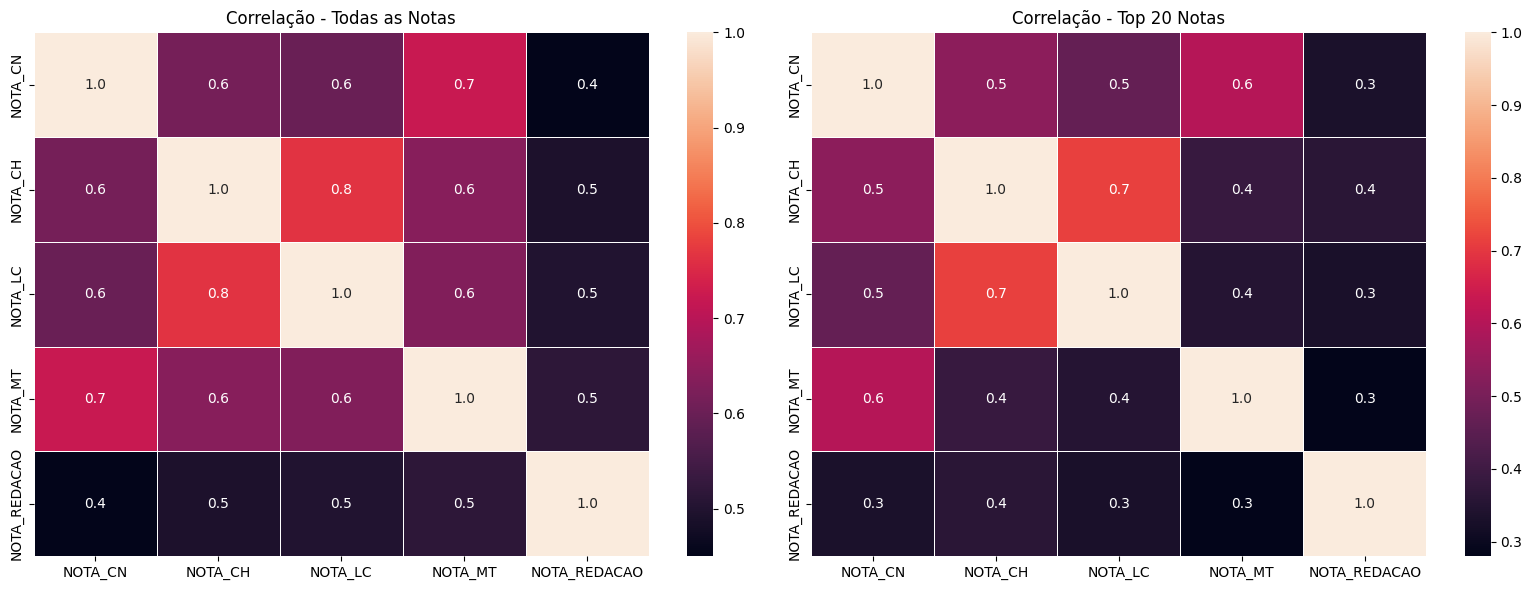

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(correlacao_notas_presentes, annot=True, fmt=".1f", linewidths=.6, ax=ax1)
ax1.set_title('Correlação - Todas as Notas')

sns.heatmap(correlacao_notas_top20, annot=True, fmt=".1f", linewidths=.6, ax=ax2)
ax2.set_title('Correlação - Top 20 Notas')

plt.tight_layout()
plt.show()

#### Box-plot das notas de redação dos candidatos presentes.

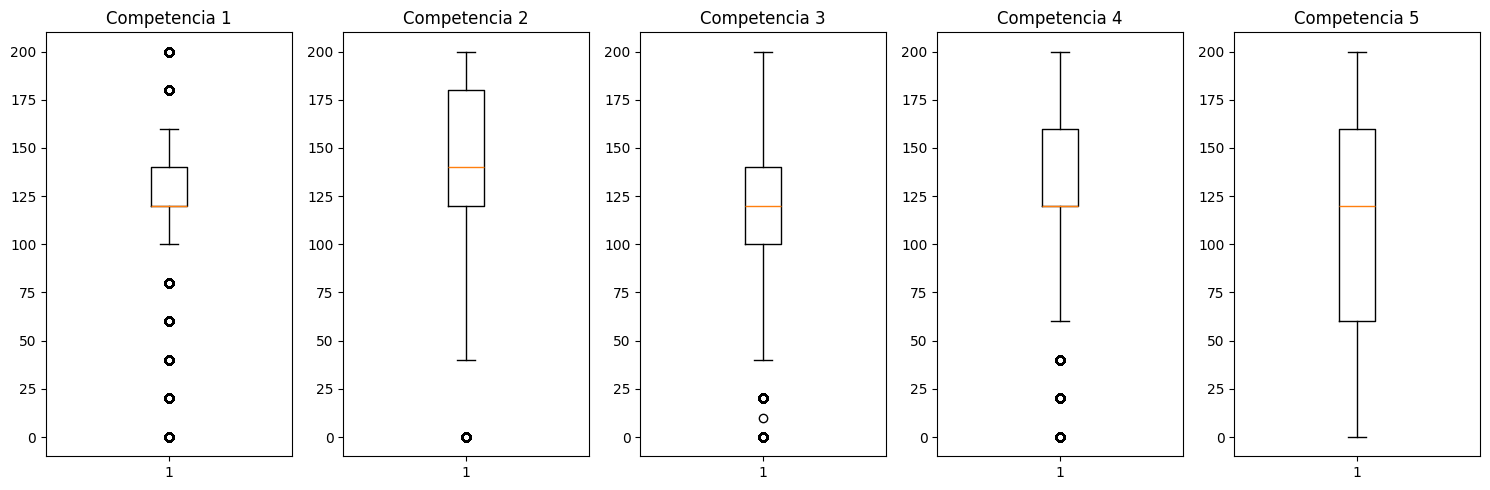

In [32]:
# Criar a figura e os subplots
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
nomes_display={'NOTA_COMP1_REDACAO': 'Competencia 1',
               'NOTA_COMP2_REDACAO': 'Competencia 2',
               'NOTA_COMP3_REDACAO': 'Competencia 3',
               'NOTA_COMP4_REDACAO': 'Competencia 4',
               'NOTA_COMP5_REDACAO': 'Competencia 5'}
    # Gerar um boxplot para cada coluna
for i, coluna in enumerate(notas_redacao_presentes_df_enem_2023.columns):
    # Usando matplotlib
    axes[i].boxplot(notas_redacao_presentes_df_enem_2023[coluna])
    titulo = nomes_display.get(coluna, coluna)
    axes[i].set_title(titulo)
    
    # Alternativamente, usando seaborn (descomente as linhas abaixo)
    # sns.boxplot(data=df, y=coluna, ax=axes[i])
    # axes[i].set_title(coluna)
    # axes[i].set_xlabel('')  # Remove o label do eixo x

plt.tight_layout()  # Ajusta o espaçamento entre os gráficos
plt.show()

#### Box-plot das notas de redação dos candidatos top20.

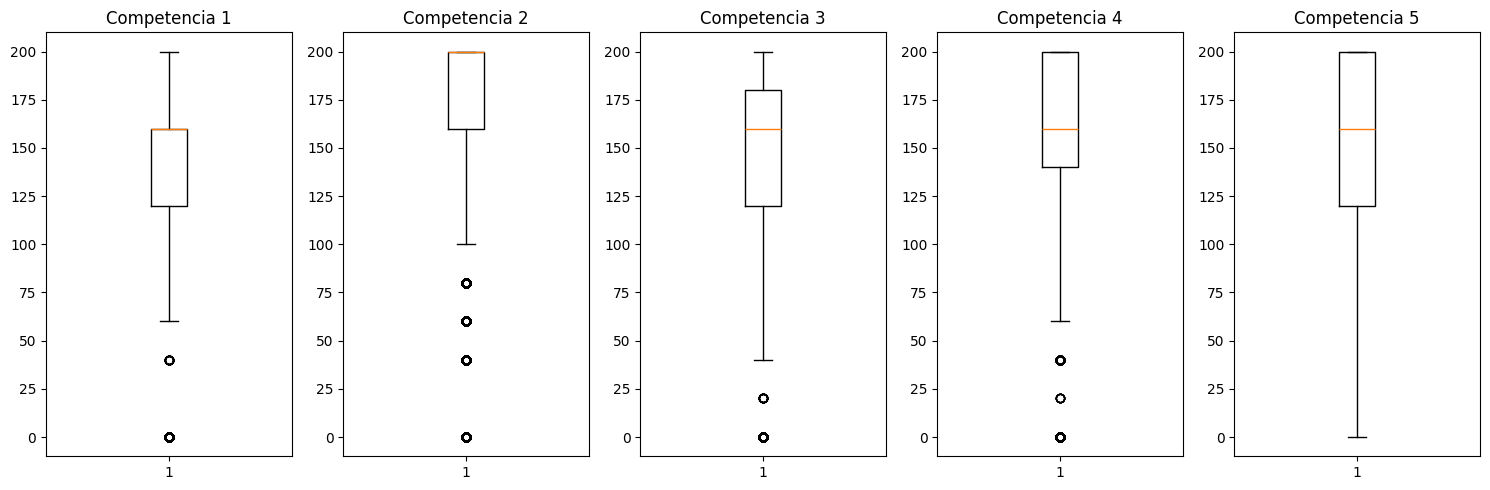

In [33]:
# Criar a figura e os subplots
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
nomes_display={'NOTA_COMP1_REDACAO': 'Competencia 1',
               'NOTA_COMP2_REDACAO': 'Competencia 2',
               'NOTA_COMP3_REDACAO': 'Competencia 3',
               'NOTA_COMP4_REDACAO': 'Competencia 4',
               'NOTA_COMP5_REDACAO': 'Competencia 5'}
    # Gerar um boxplot para cada coluna
for i, coluna in enumerate(notas_redacao_top20_df_enem_2023.columns):
    # Usando matplotlib
    axes[i].boxplot(notas_redacao_top20_df_enem_2023[coluna])
    titulo = nomes_display.get(coluna, coluna)
    axes[i].set_title(titulo)
    
    # Alternativamente, usando seaborn (descomente as linhas abaixo)
    # sns.boxplot(data=df, y=coluna, ax=axes[i])
    # axes[i].set_title(coluna)
    # axes[i].set_xlabel('')  # Remove o label do eixo x

plt.tight_layout()  # Ajusta o espaçamento entre os gráficos
plt.show()

#### Box-plot das médias dos candidatos presentes.

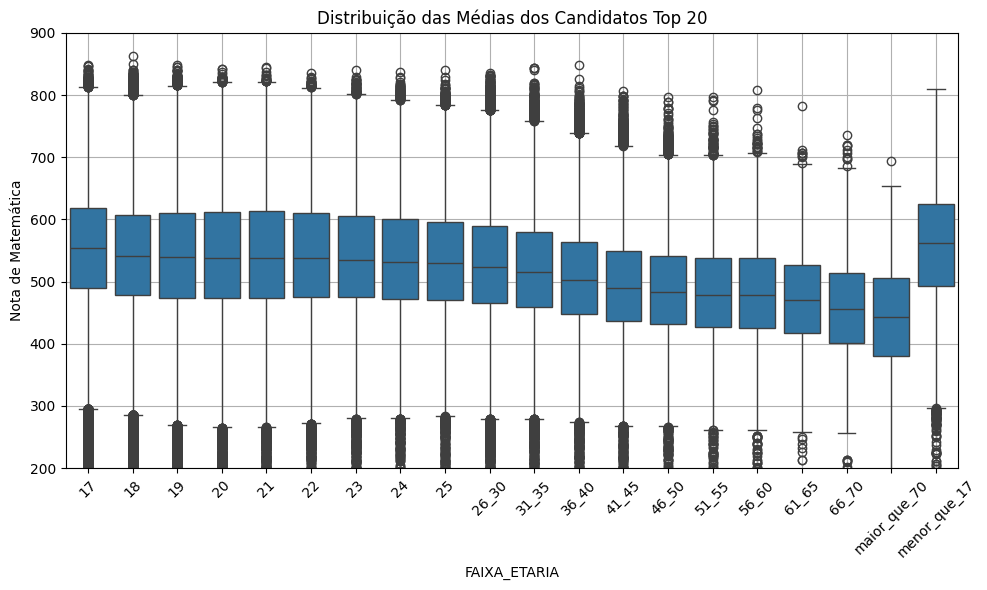

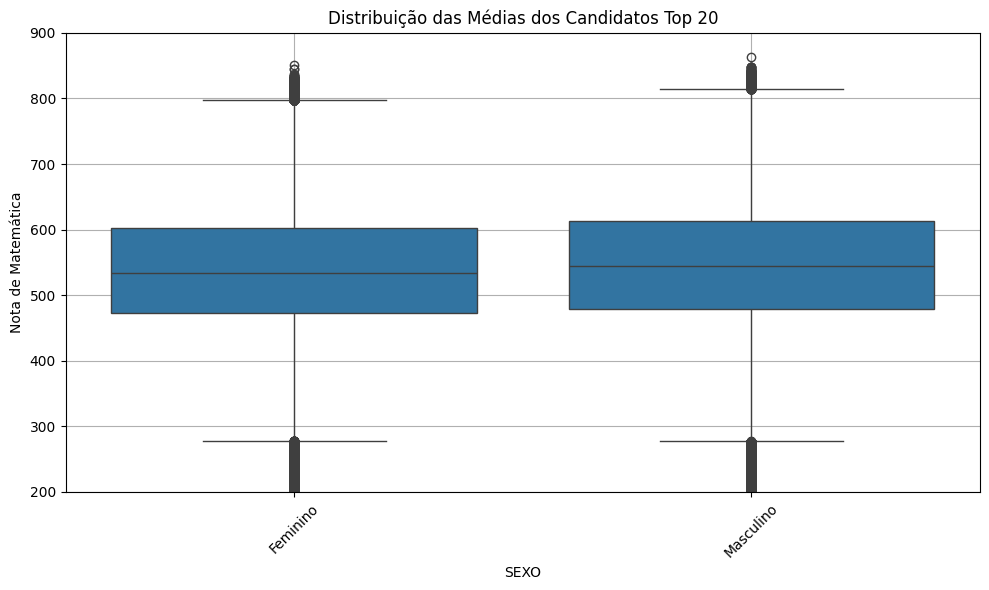

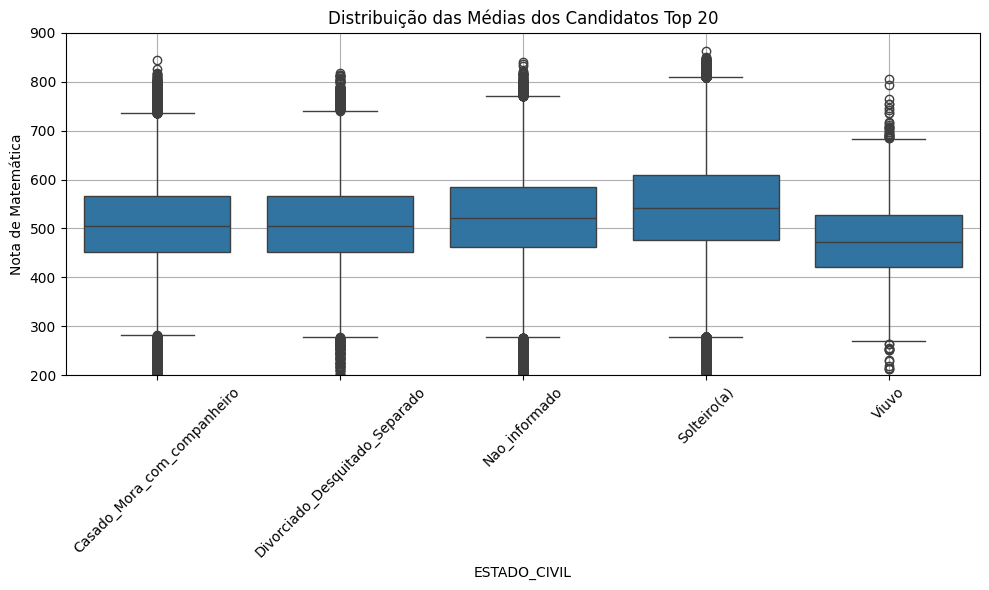

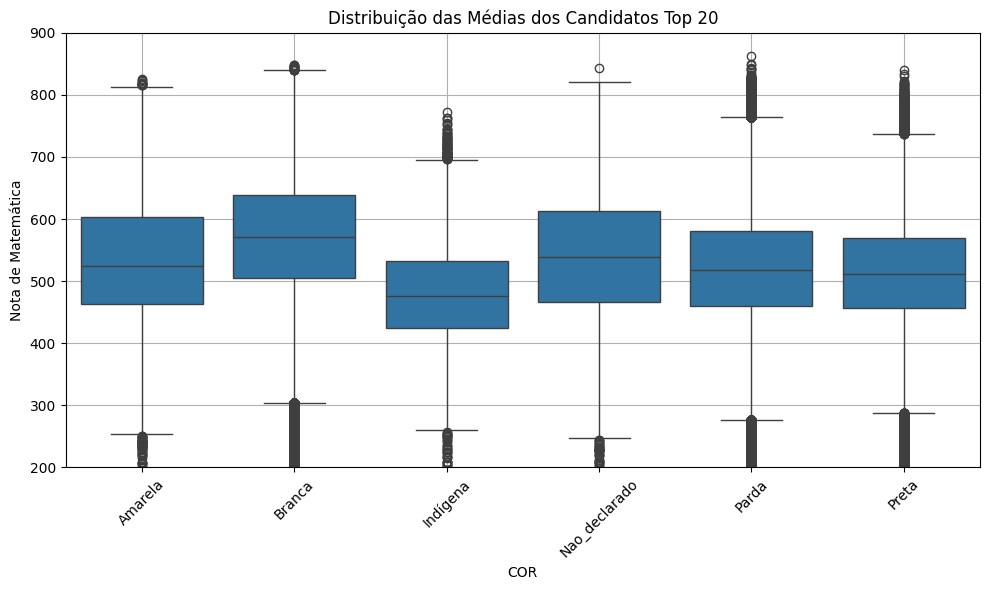

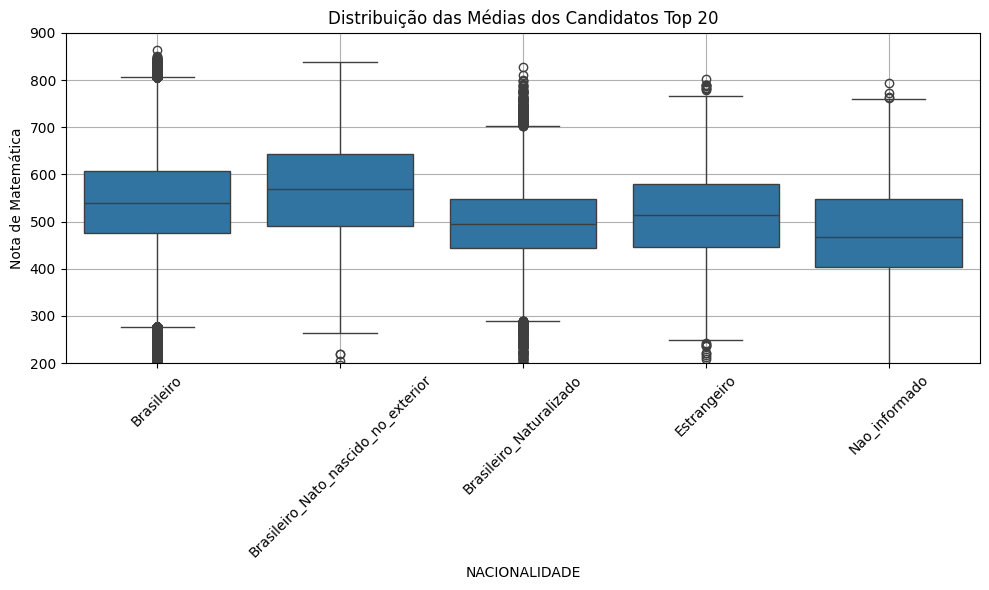

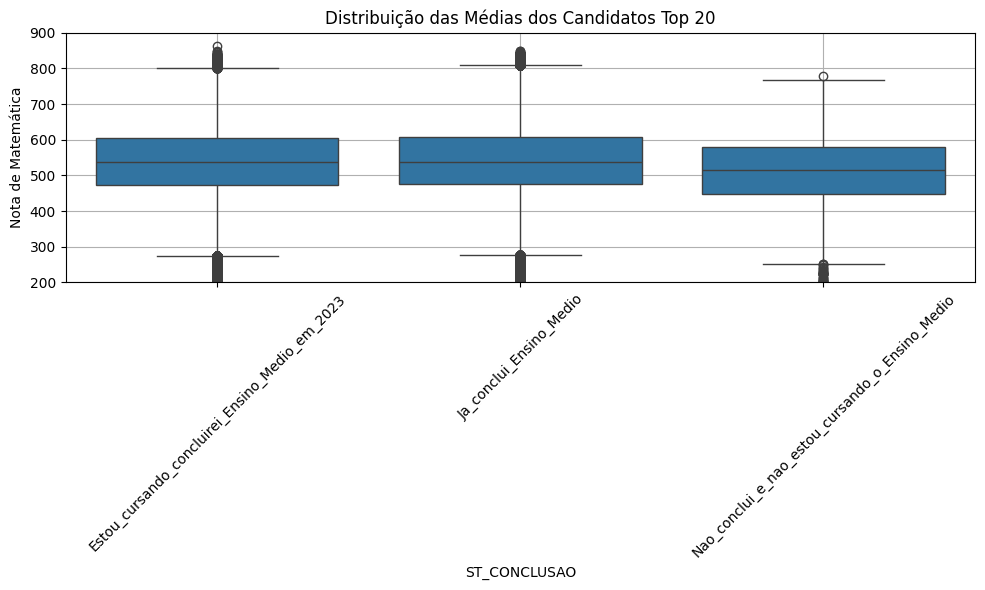

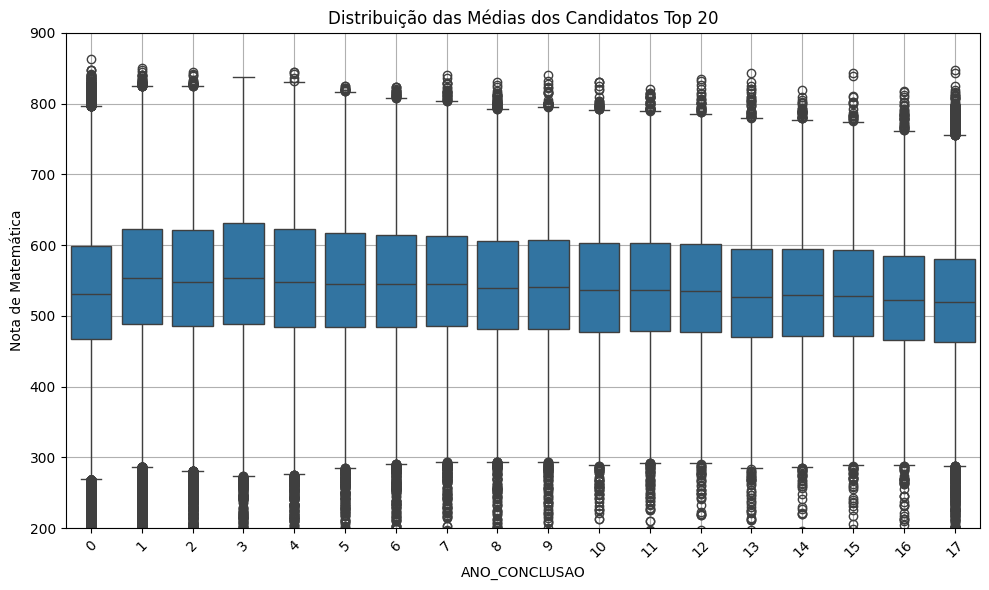

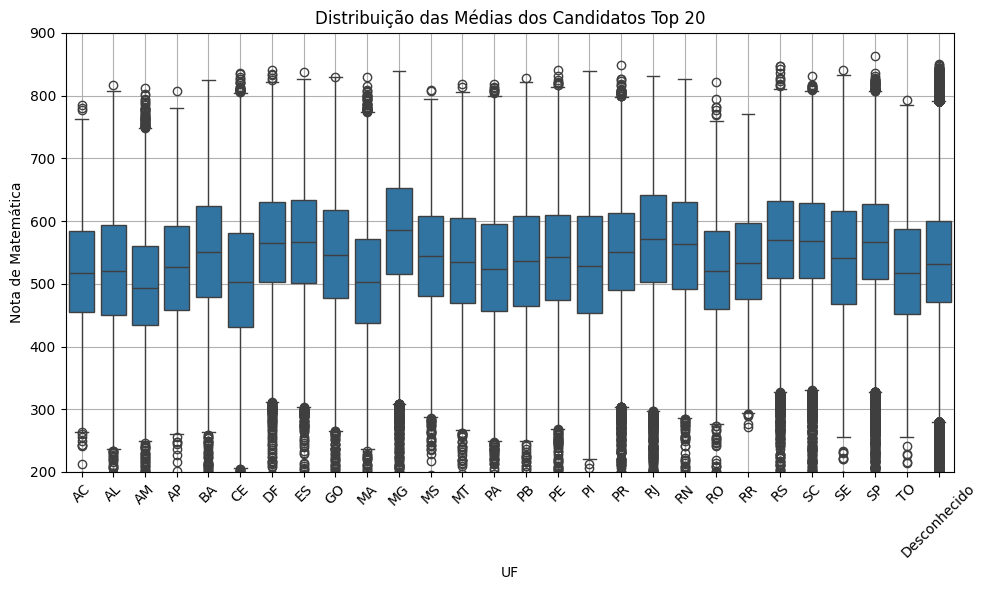

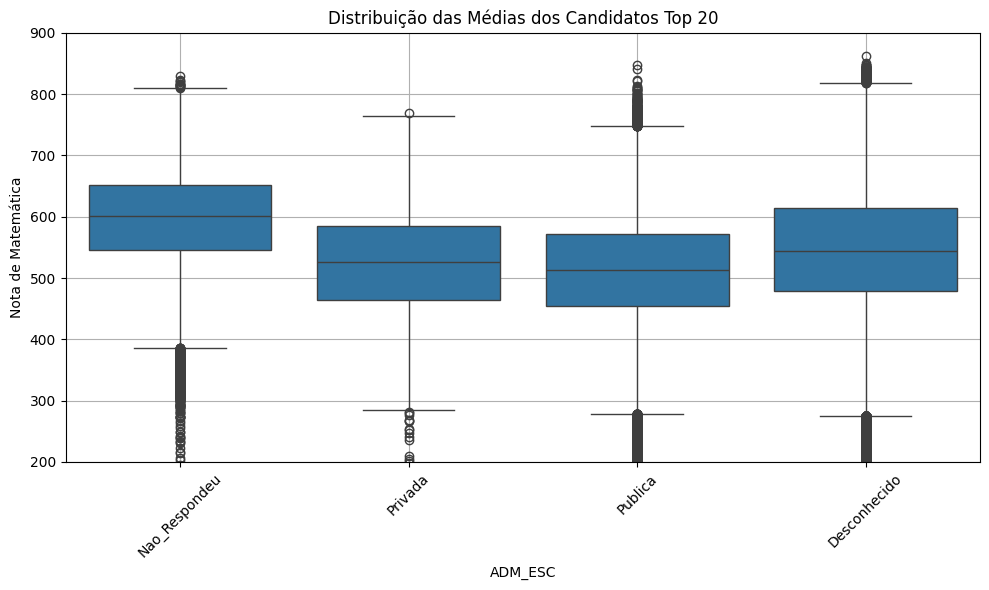

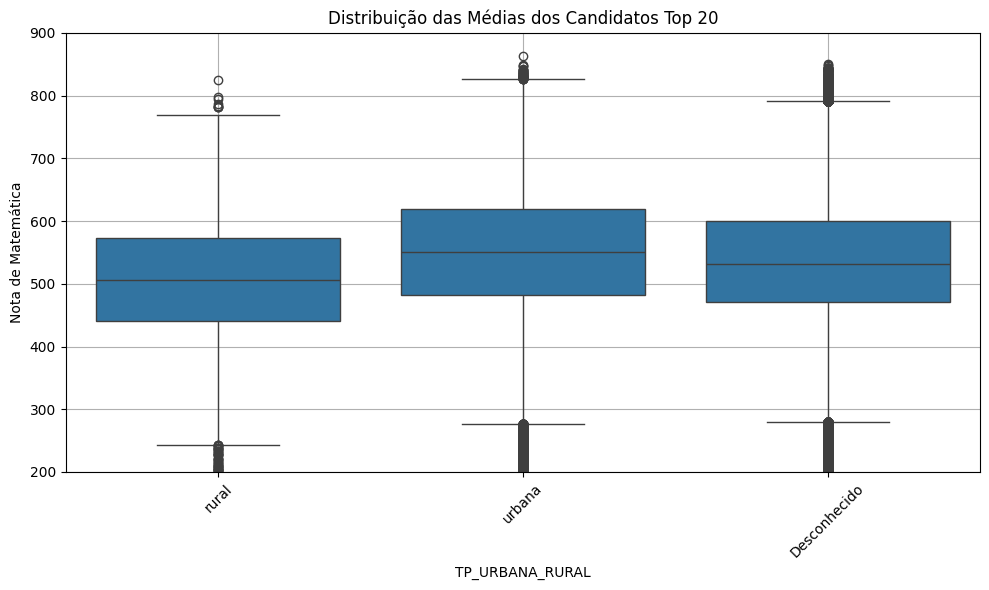

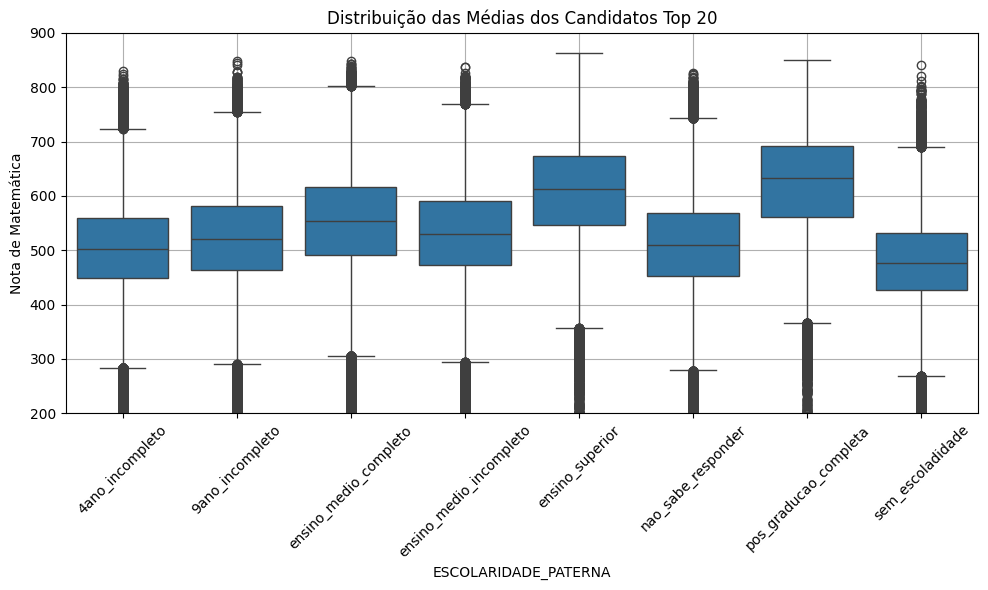

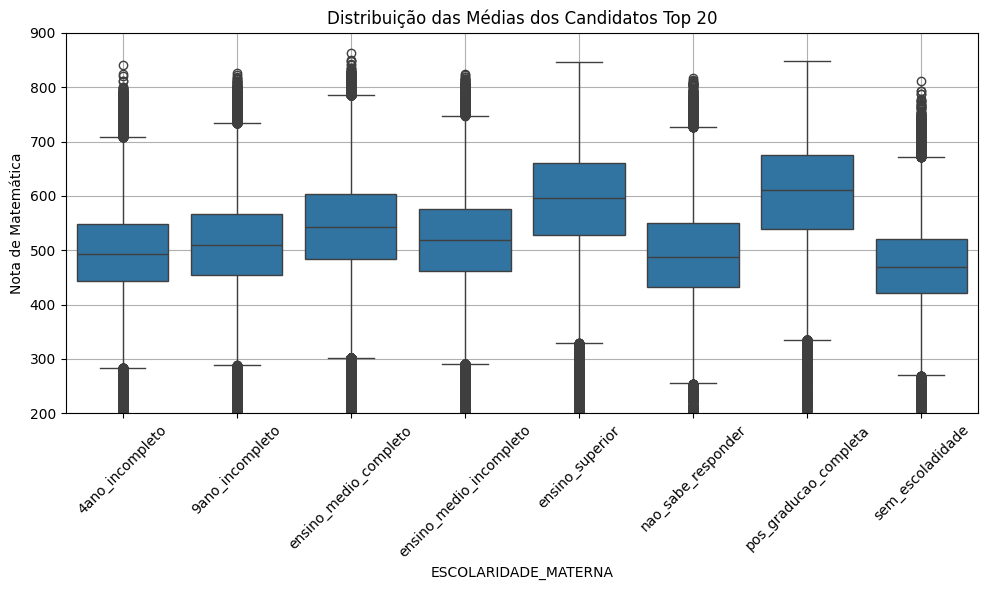

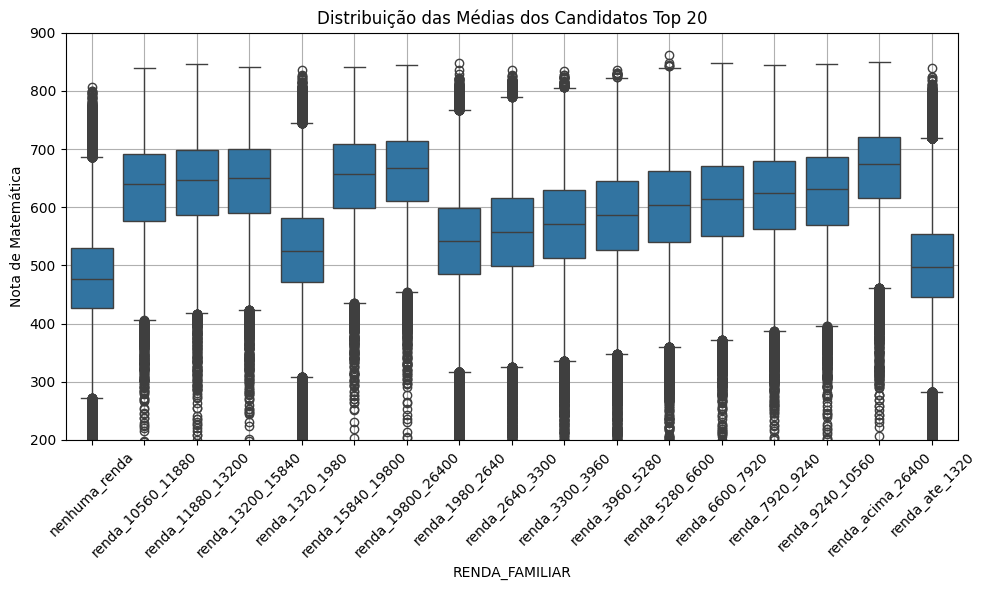

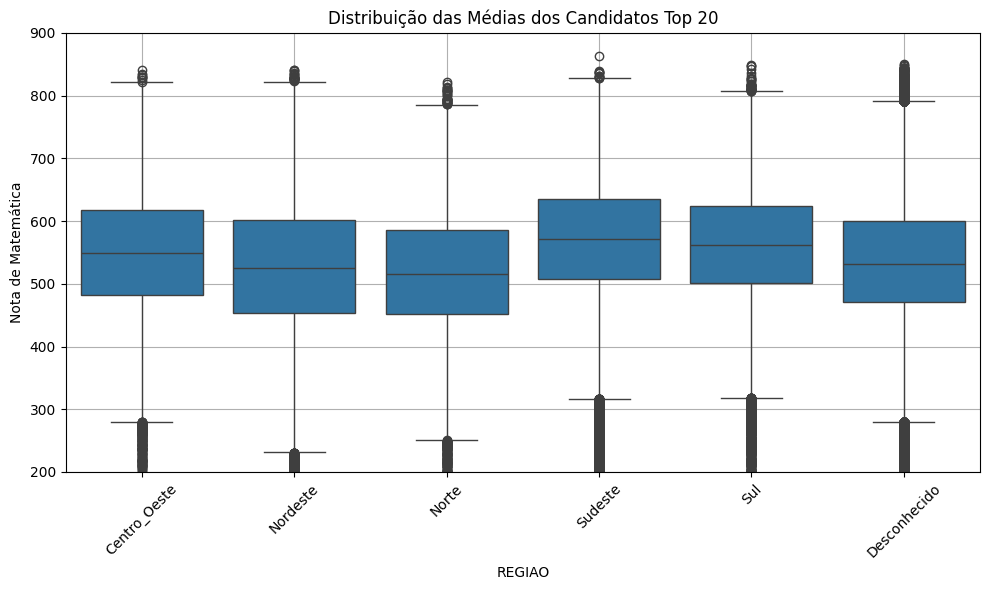

In [34]:
for cat in categoricas:    
    df_melt = presentes_df_enem_2023.melt(
        id_vars=cat,
        value_vars=['MEDIA'],
        var_name='Área',
        value_name='Nota'
    )

    # Um único gráfico com boxplots por REGIAO
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_melt, x=cat, y='Nota')

    plt.title(f'Distribuição das Médias dos Candidatos Top 20')
    plt.ylabel('Nota de Matemática')
    plt.ylim(200, 900)
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

#### Box-plot das médias dos candidatos top20.

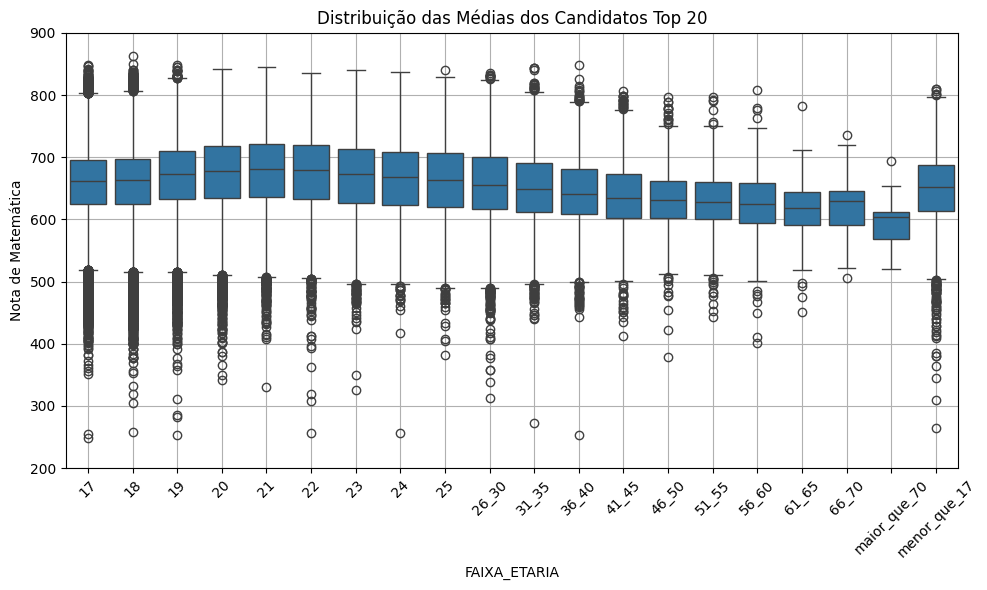

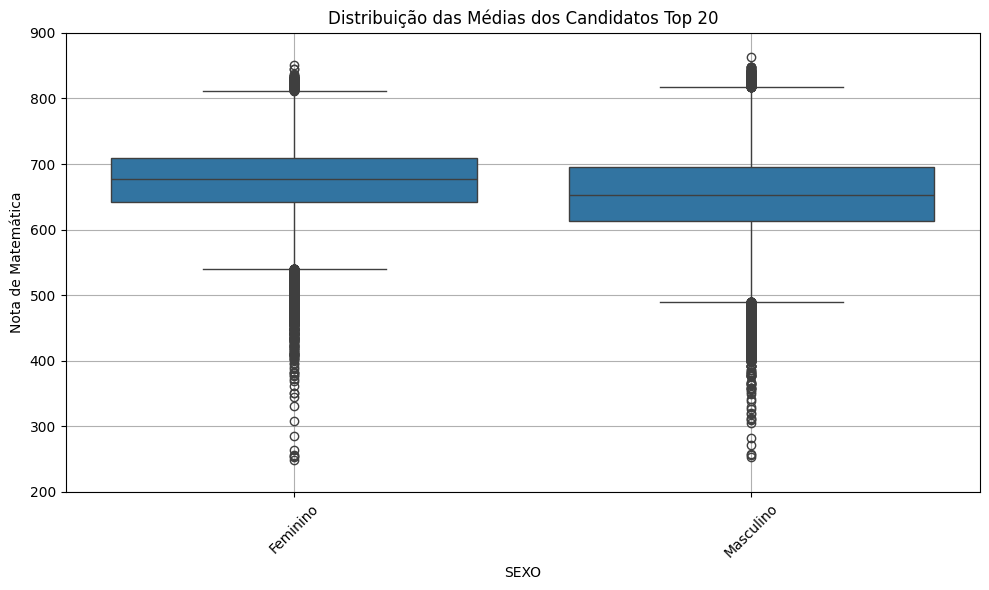

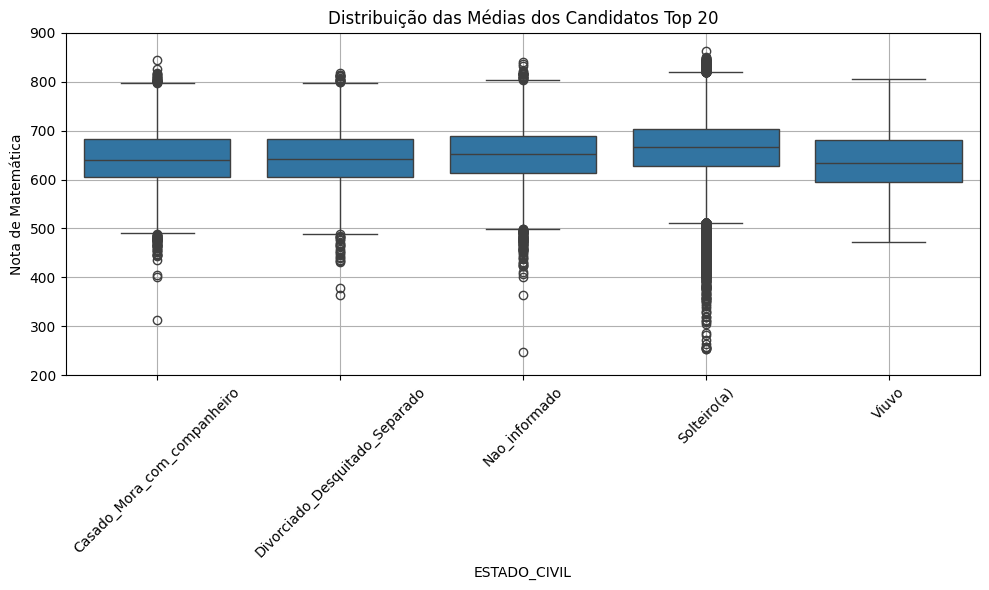

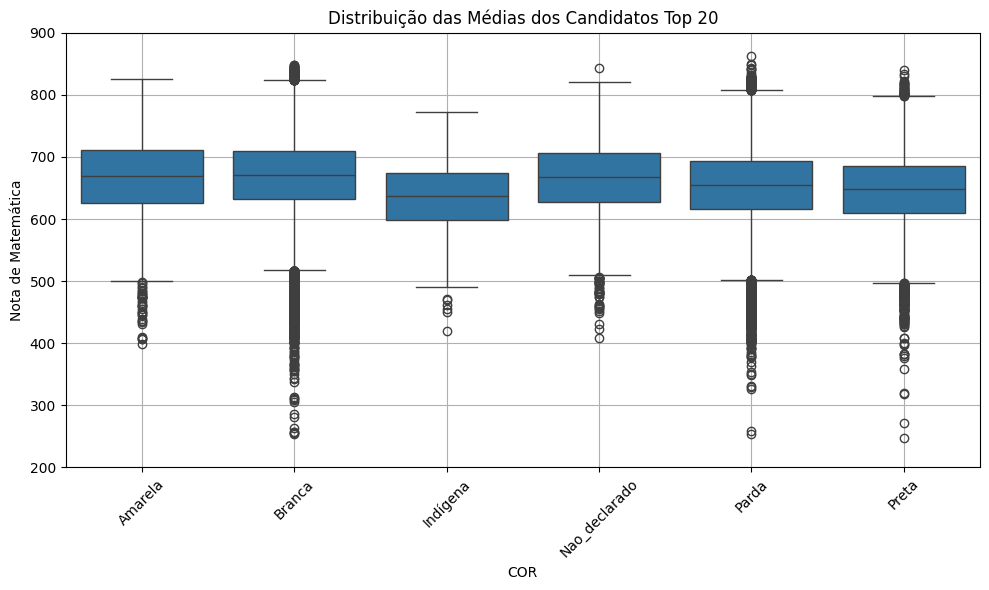

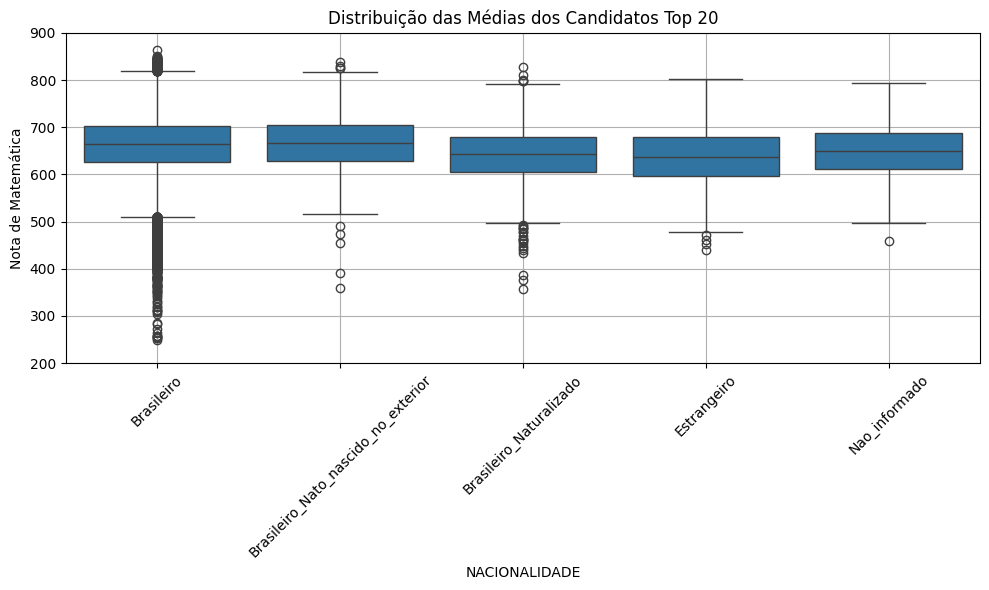

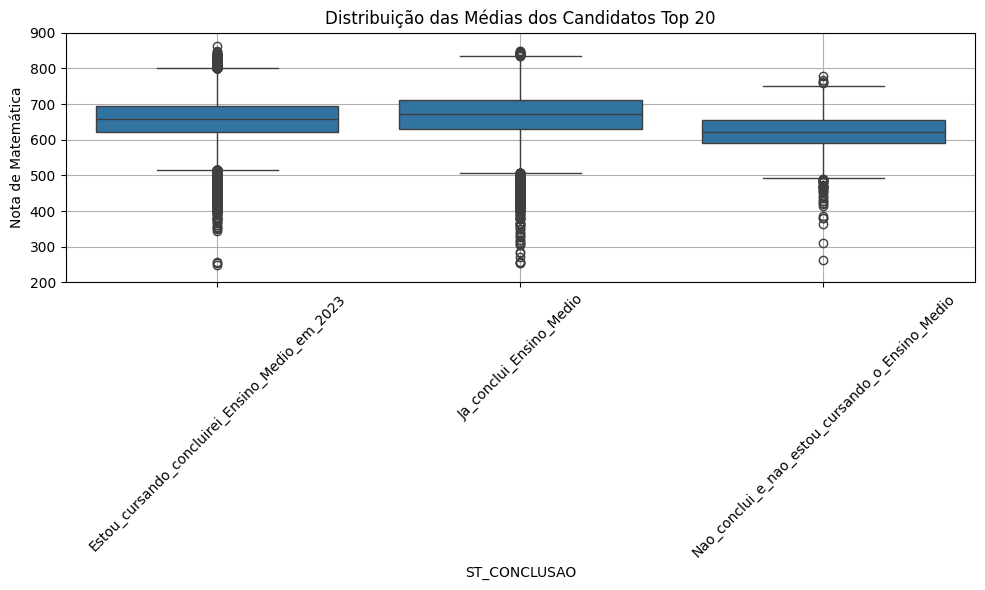

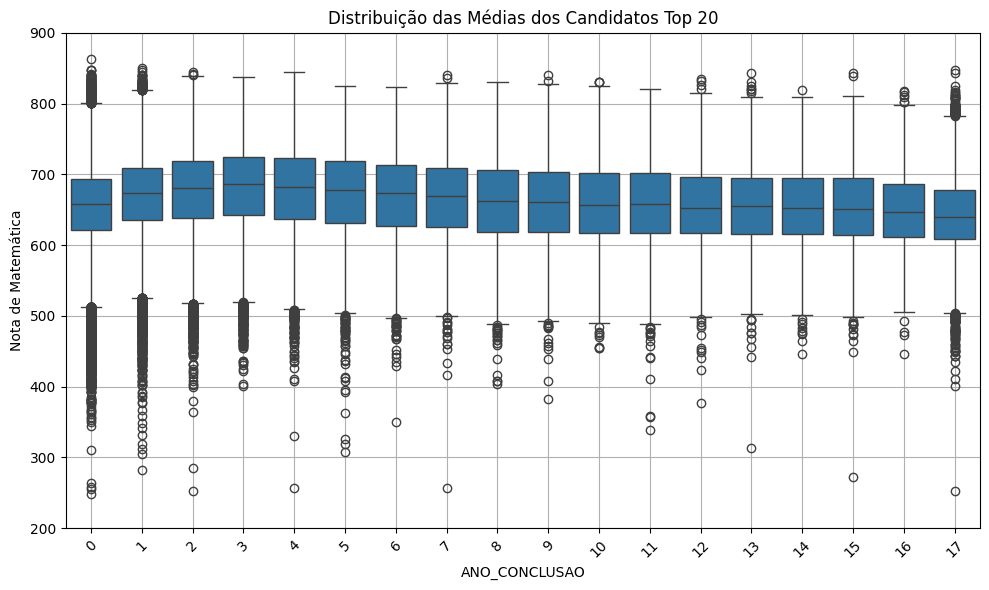

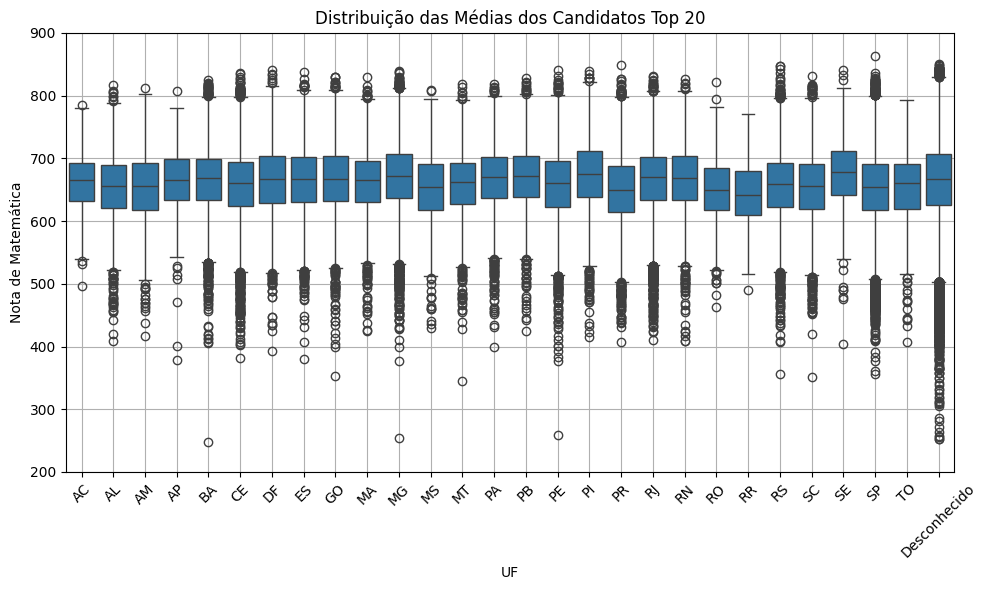

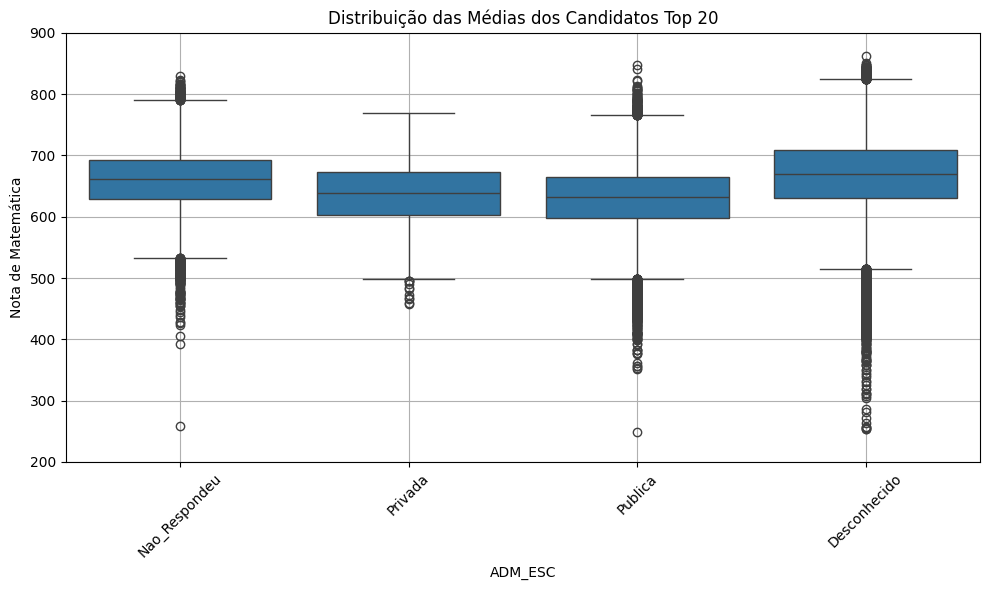

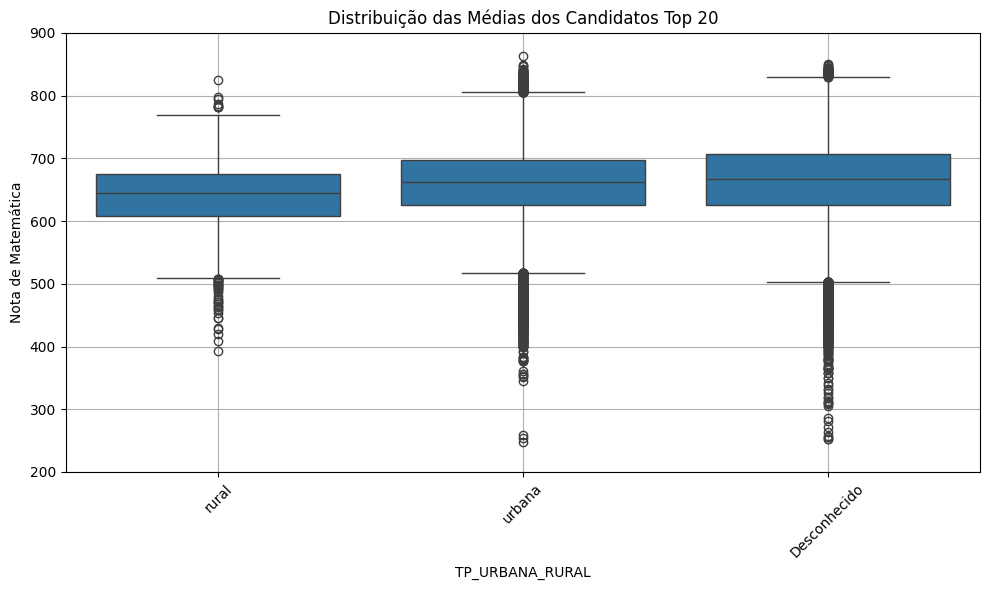

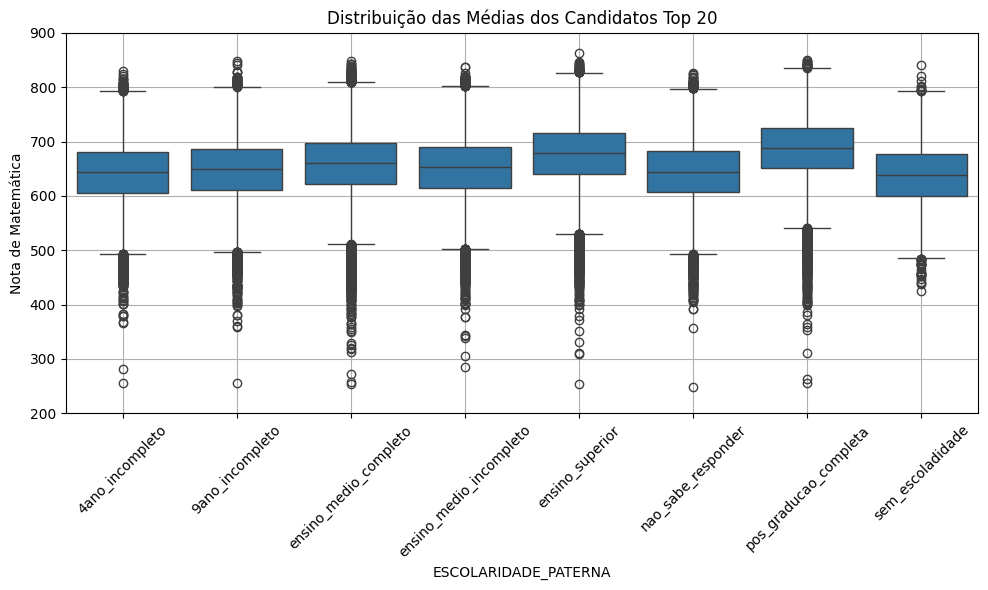

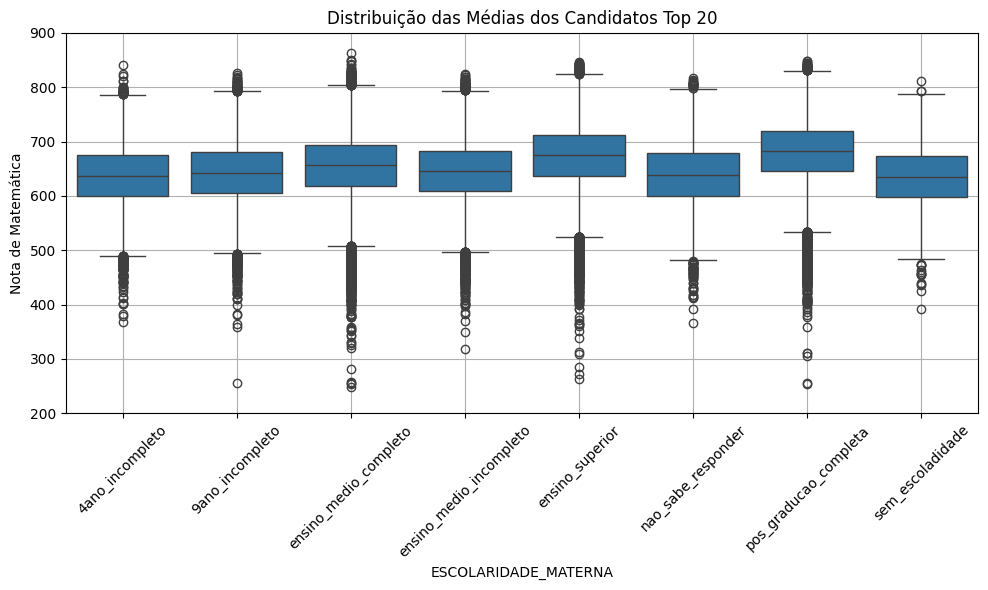

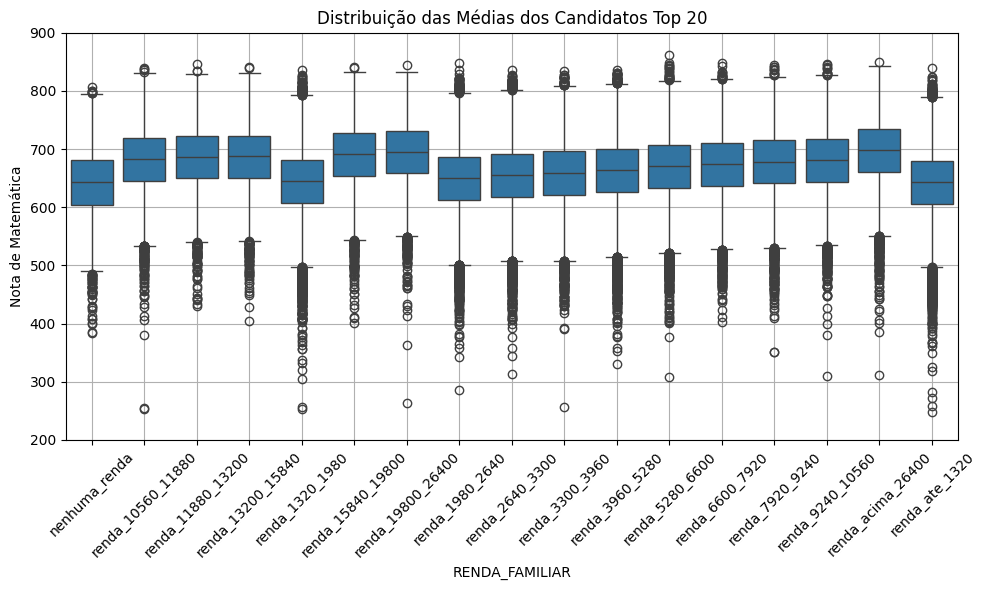

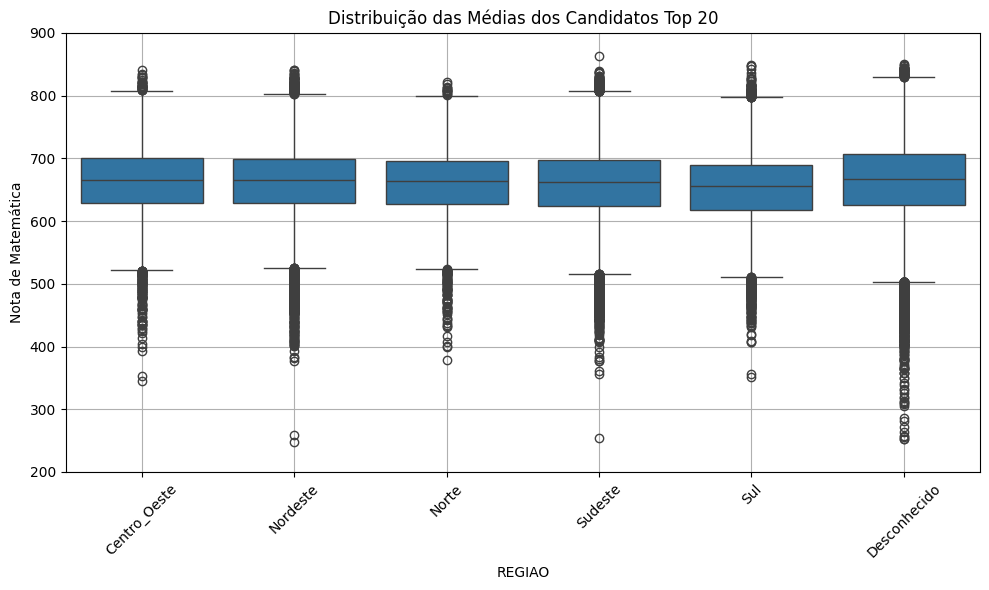

In [35]:
for cat in categoricas:    
    df_melt = top_20.melt(
        id_vars=cat,
        value_vars=['MEDIA'],
        var_name='Área',
        value_name='Nota'
    )

    # Um único gráfico com boxplots por REGIAO
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_melt, x=cat, y='Nota')

    plt.title(f'Distribuição das Médias dos Candidatos Top 20')
    plt.ylabel('Nota de Matemática')
    plt.ylim(200, 900)
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

#### Box-plot das notas de matemática dos candidatos presentes.

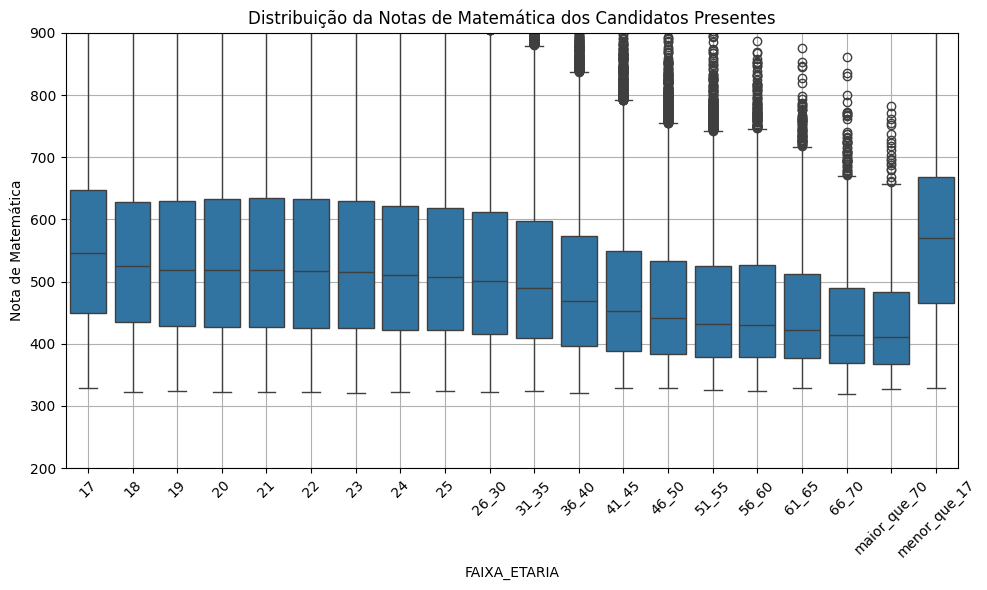

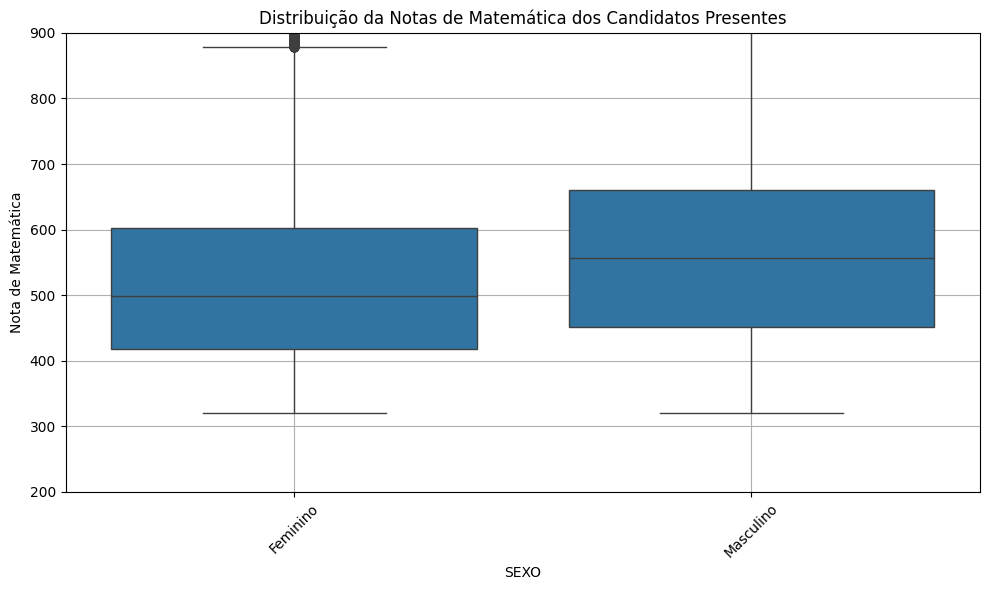

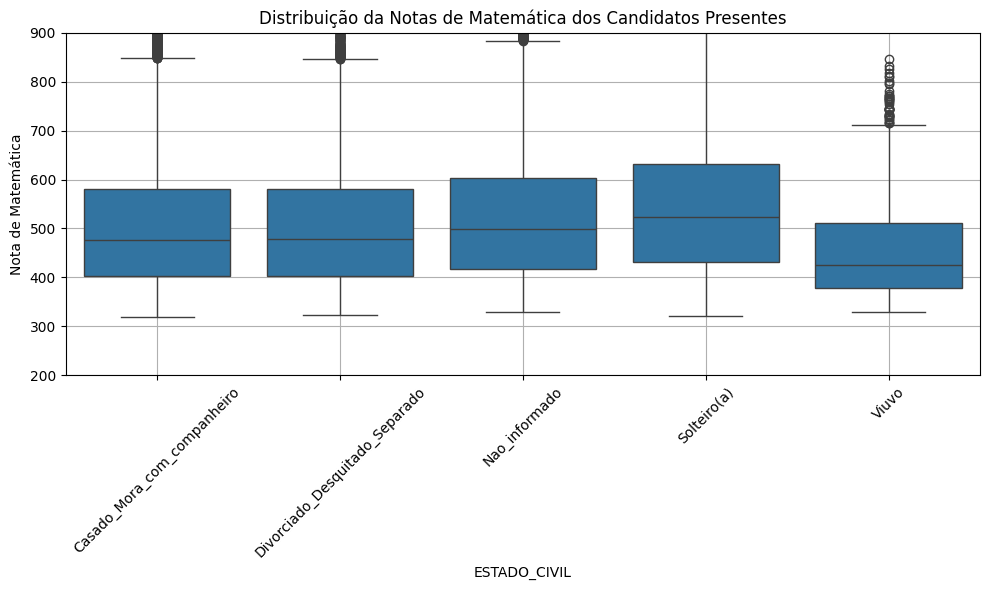

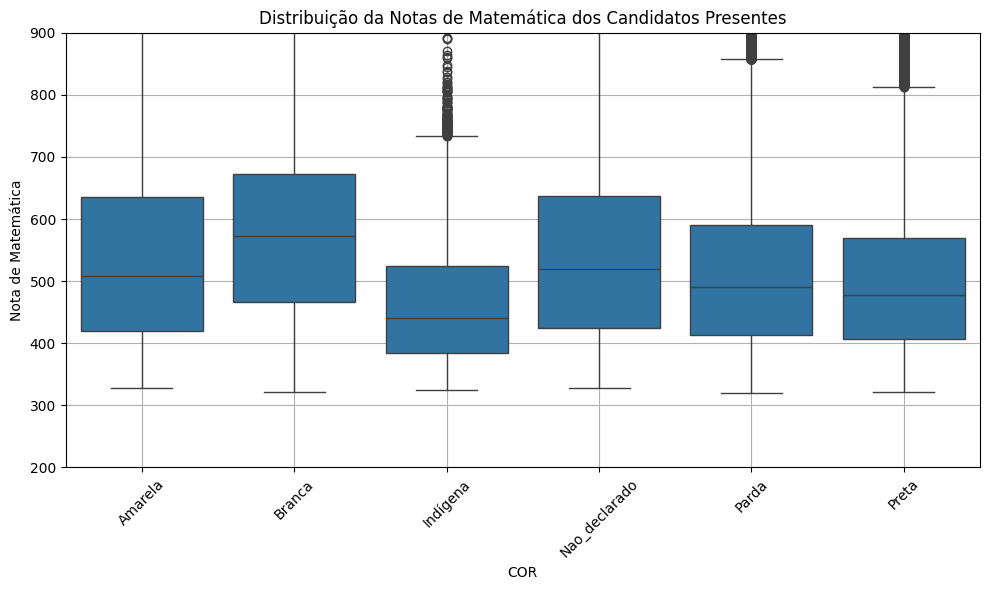

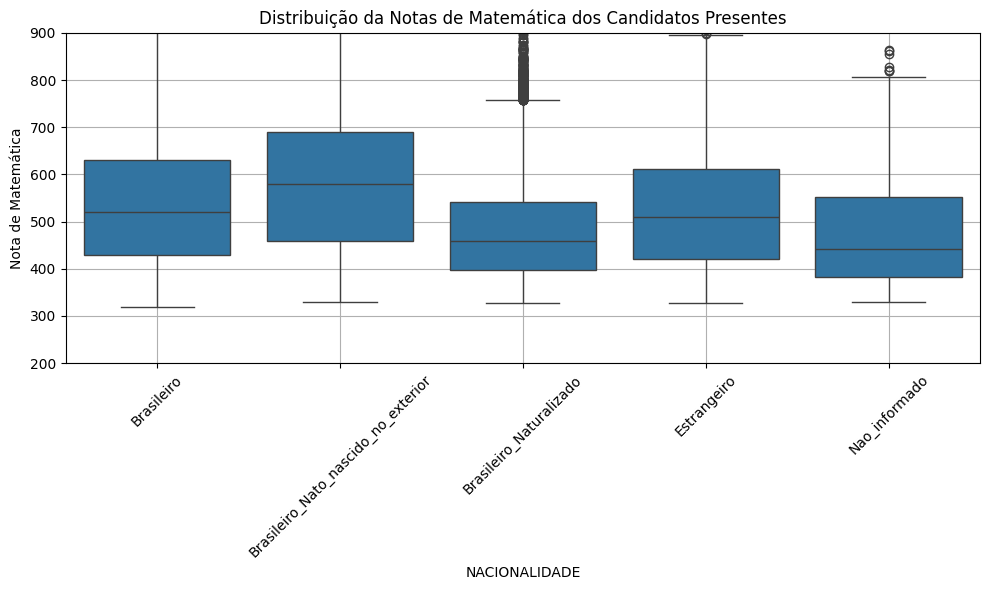

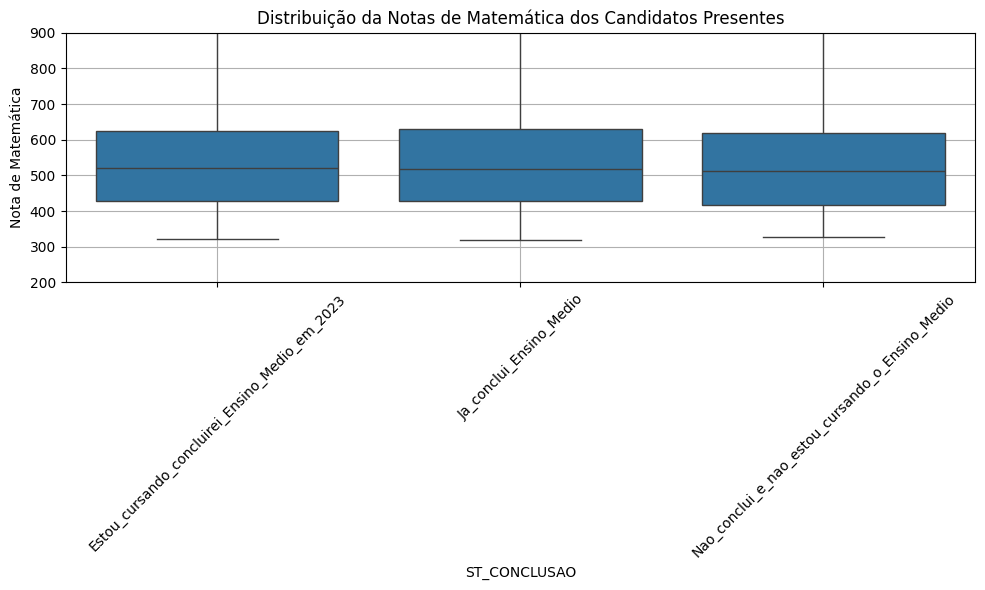

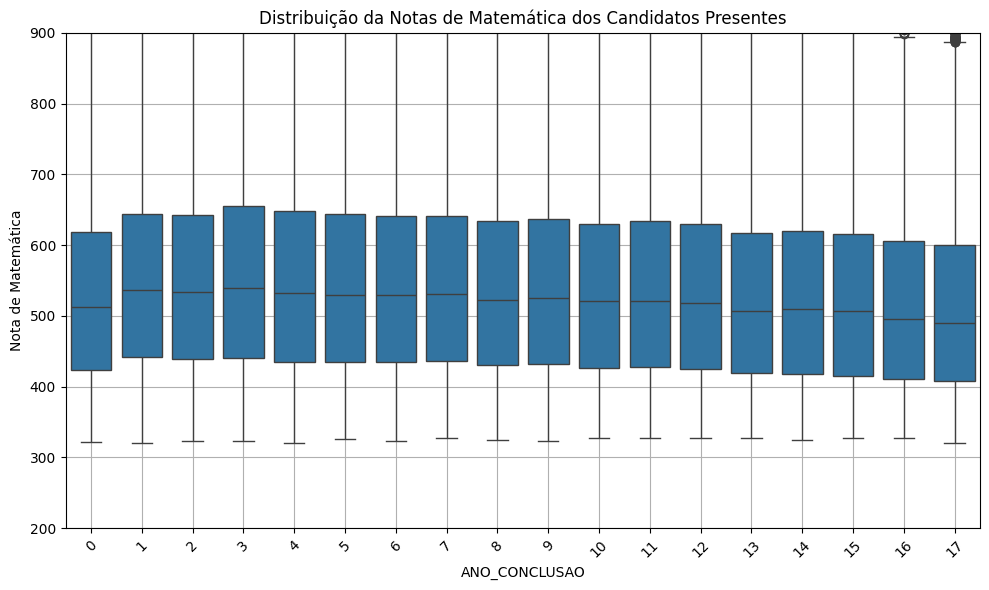

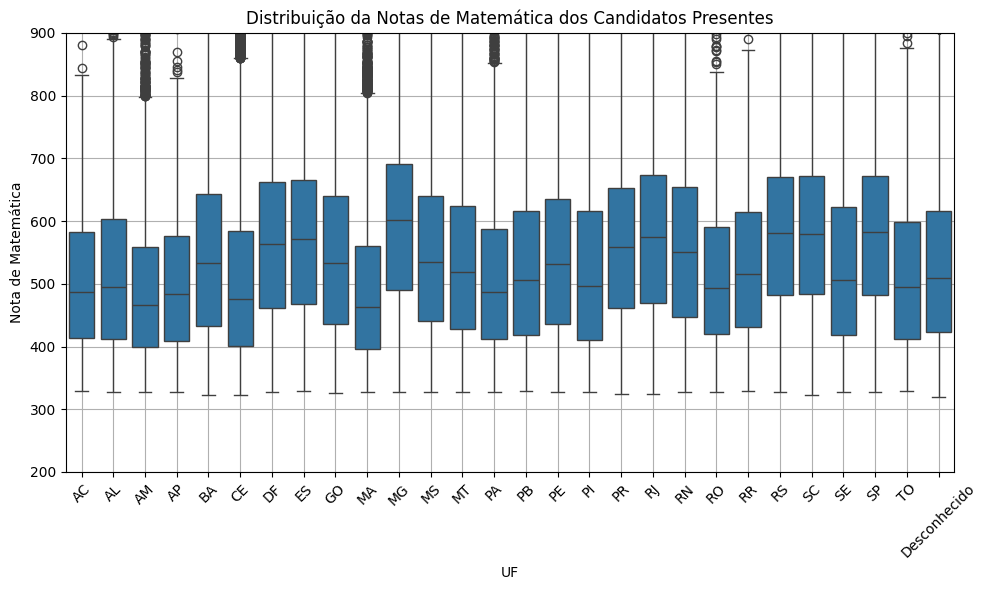

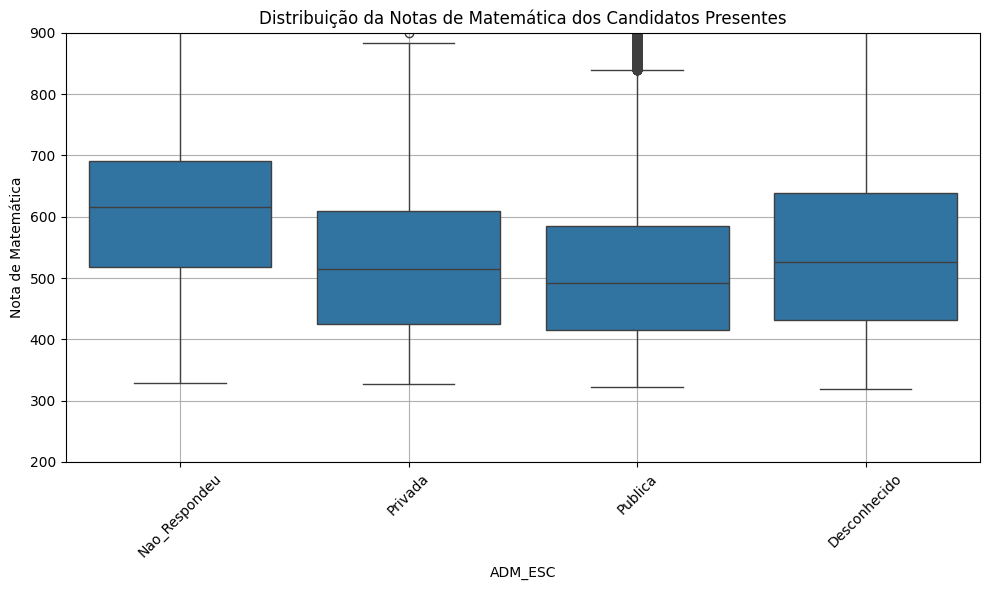

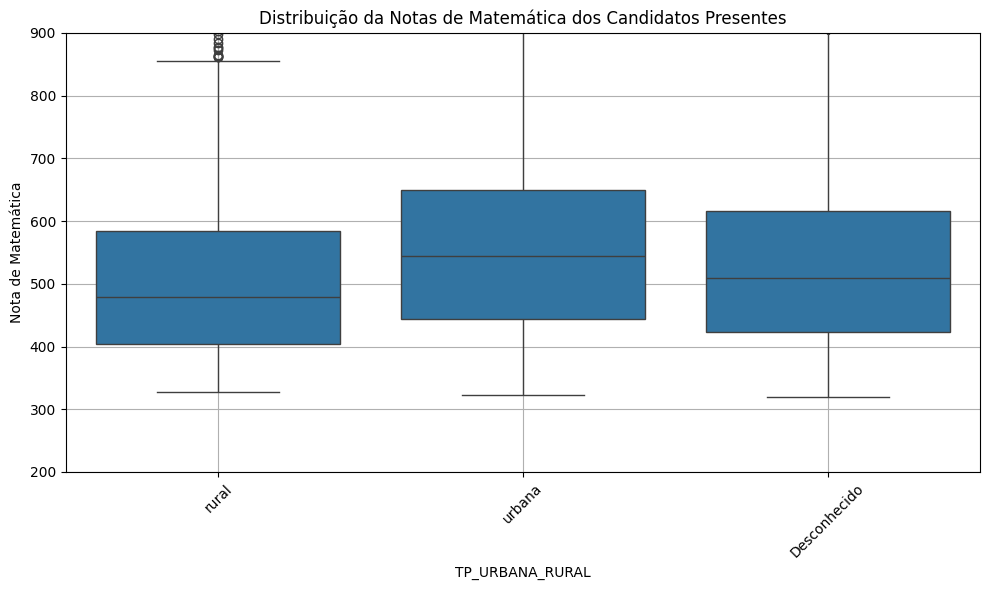

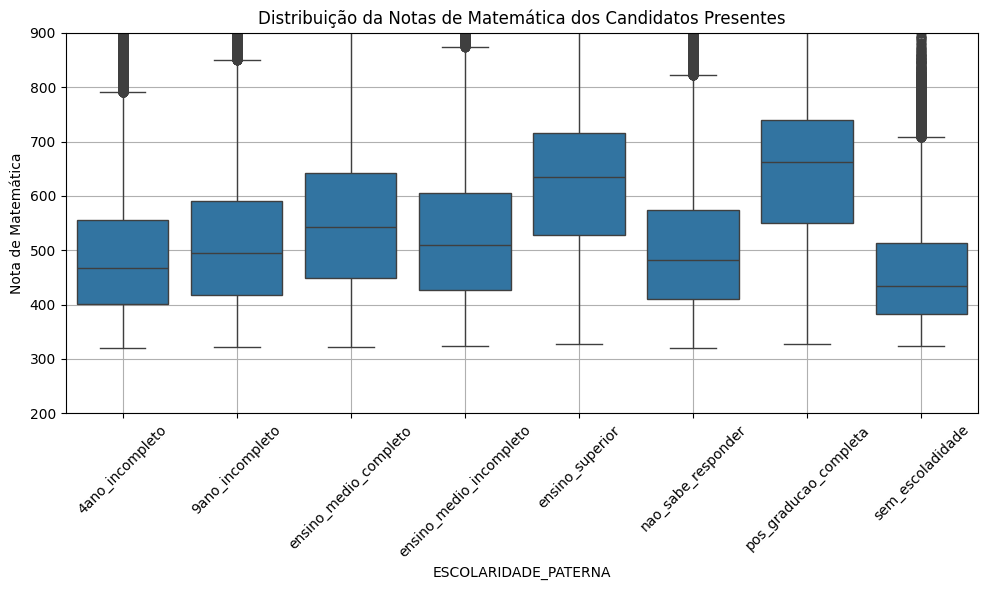

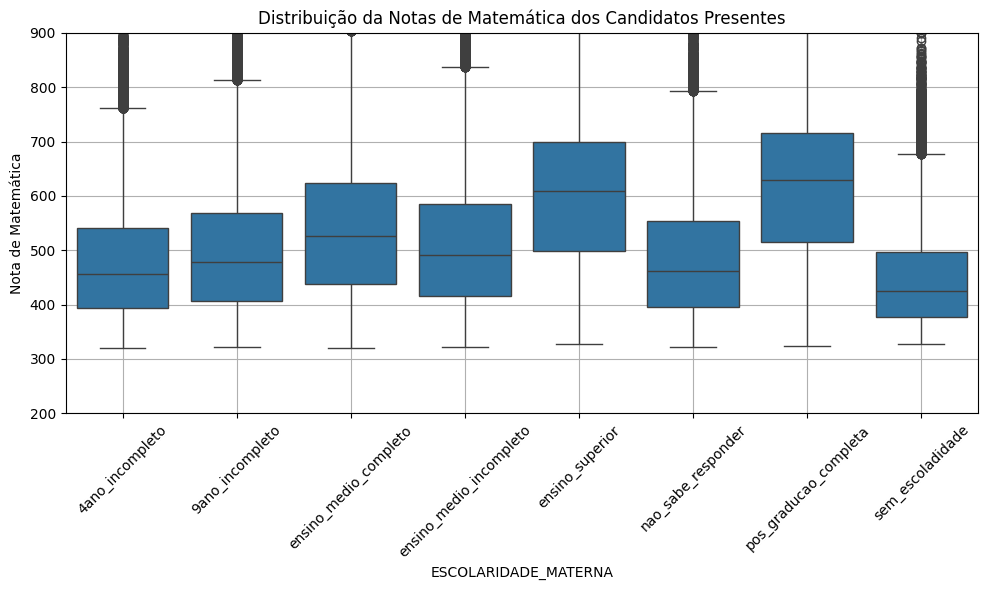

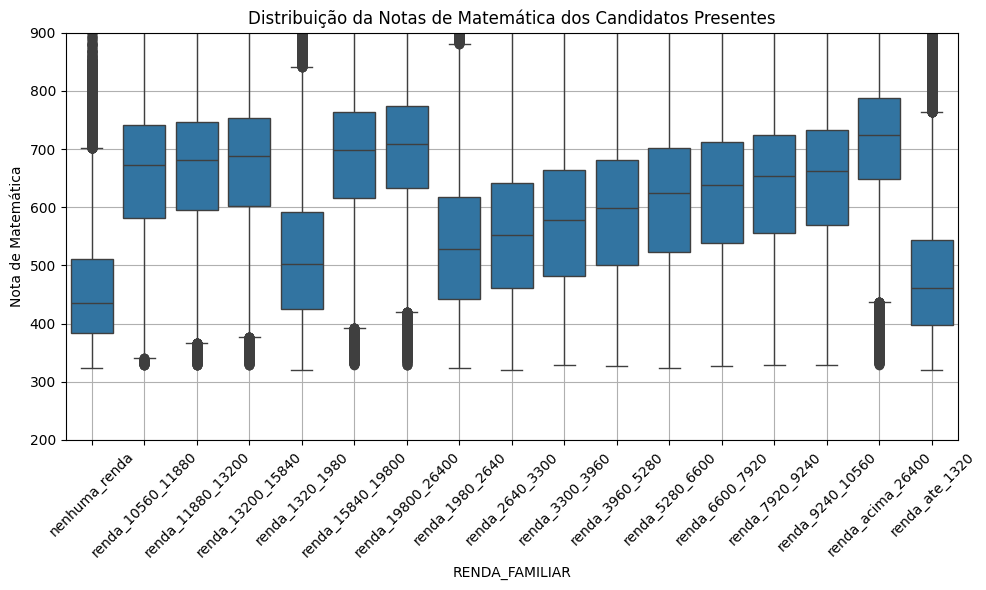

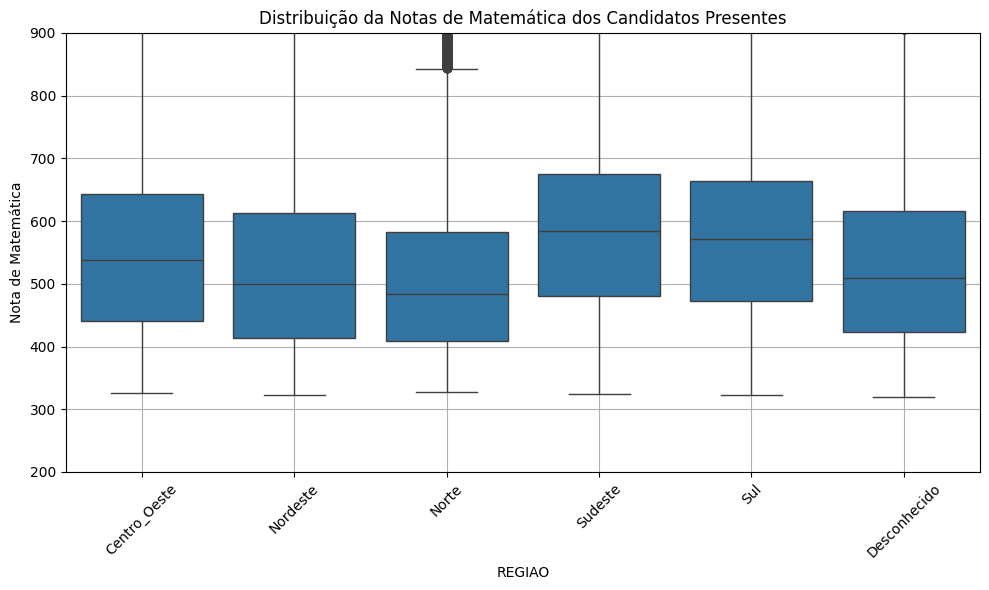

In [36]:
for cat in categoricas:    
    df_melt = presentes_df_enem_2023.melt(
        id_vars=cat,
        value_vars=['NOTA_MT'],
        var_name='Área',
        value_name='Nota'
    )

    # Um único gráfico com boxplots por REGIAO
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_melt, x=cat, y='Nota')

    plt.title(f'Distribuição da Notas de Matemática dos Candidatos Presentes')
    plt.ylabel('Nota de Matemática')
    plt.ylim(200, 900)
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

#### Box-plot das notas de matemática dos candidatos top20.

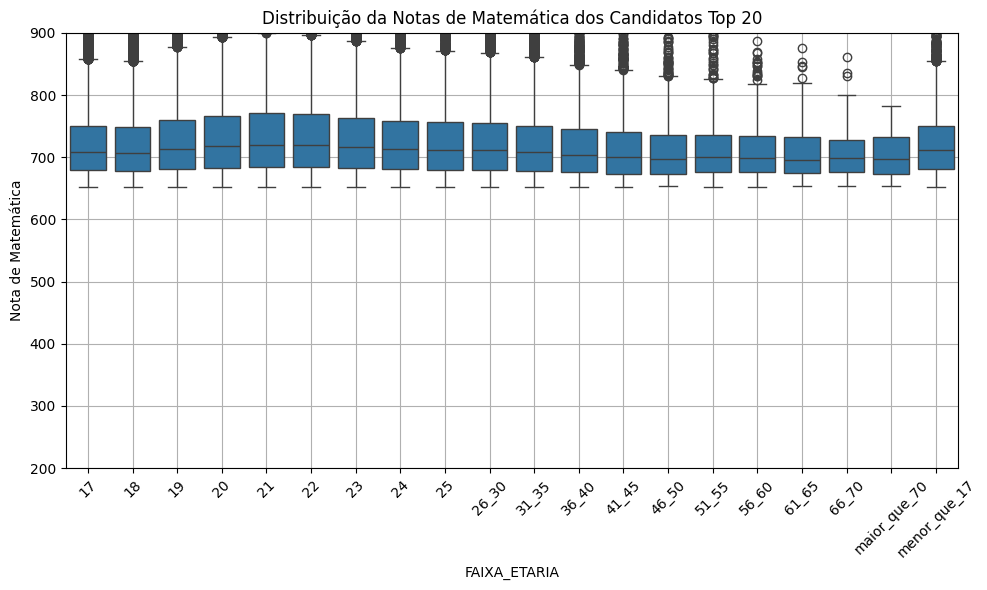

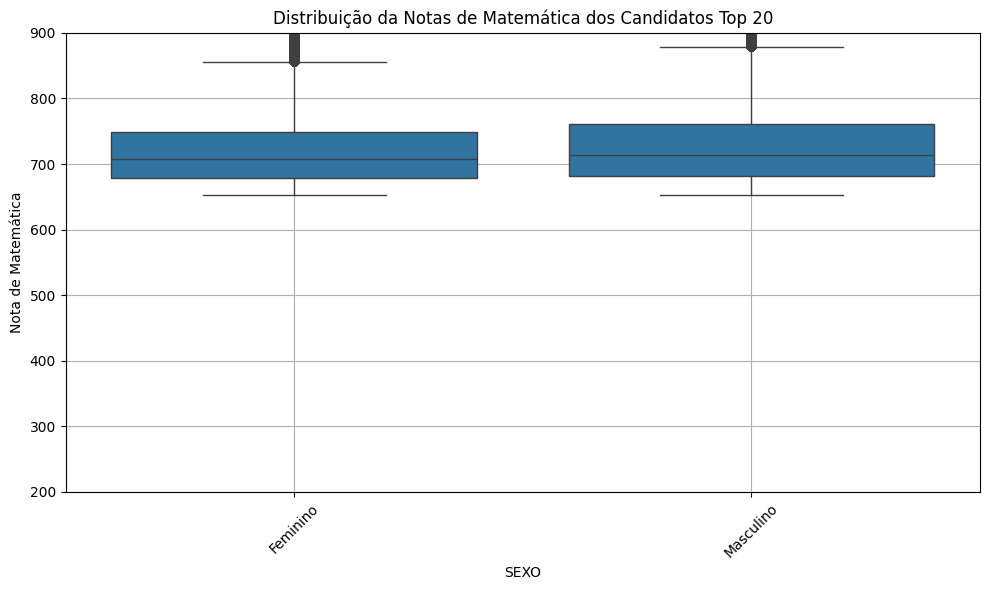

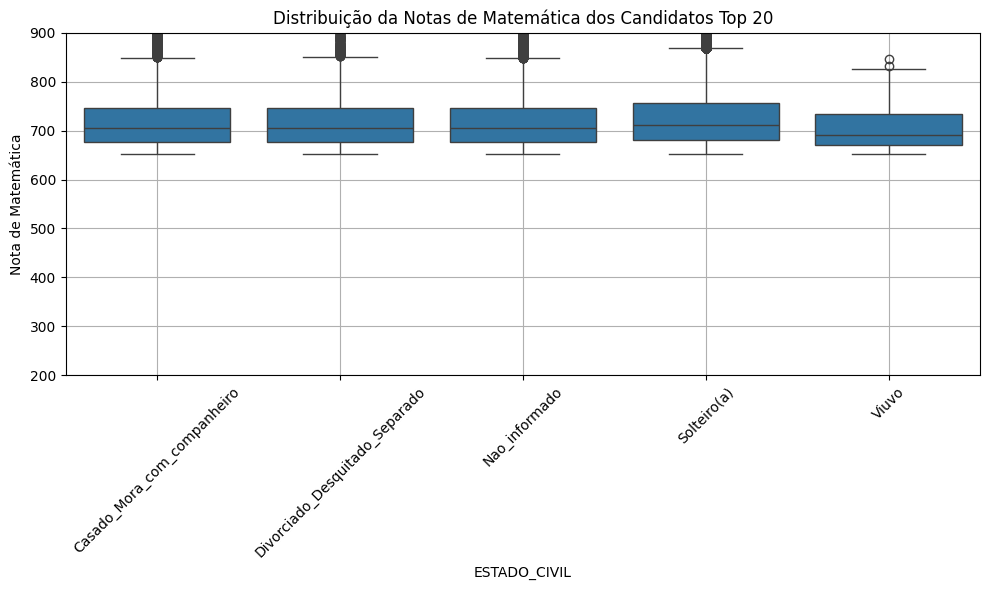

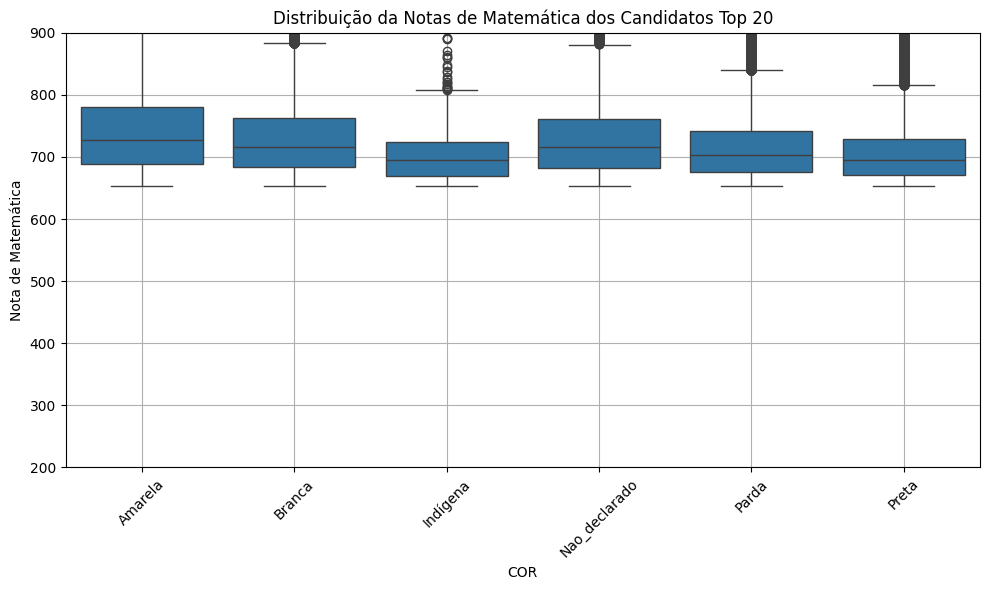

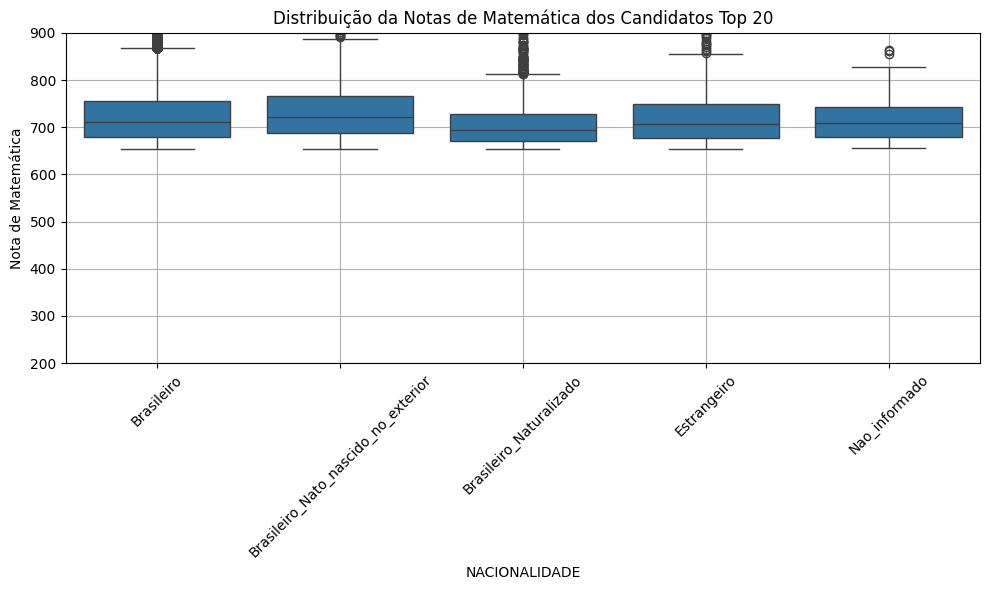

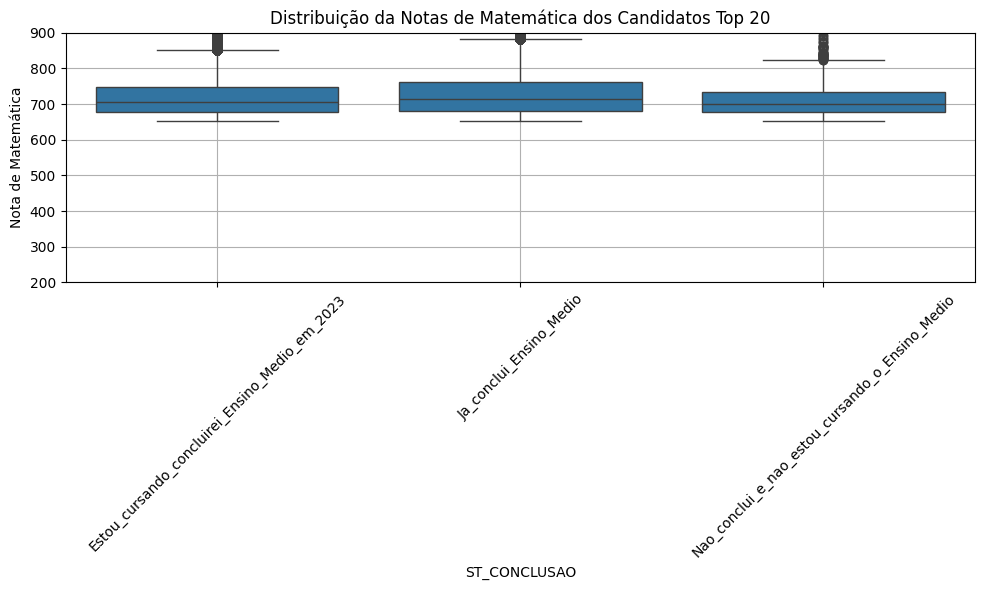

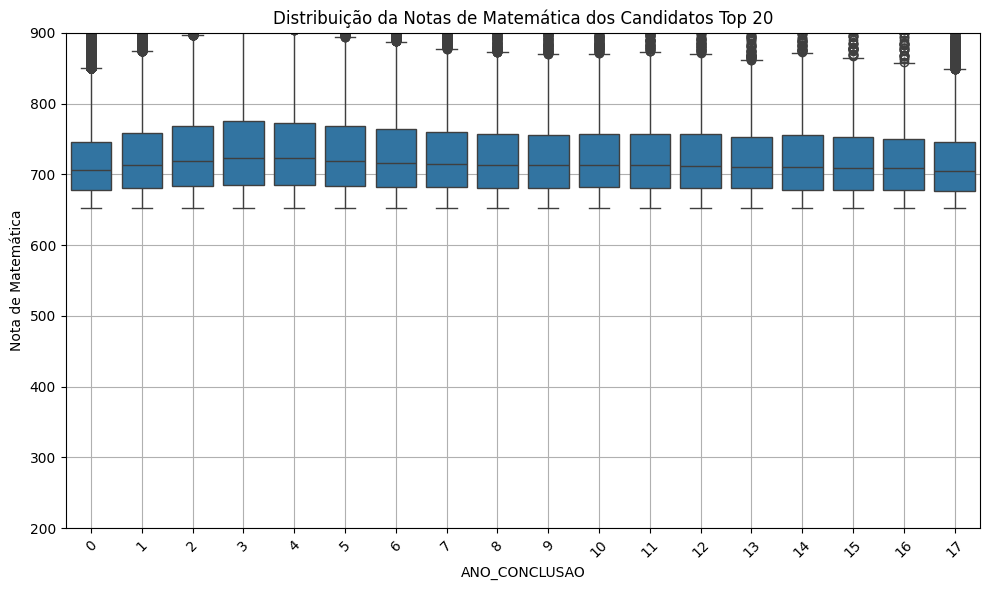

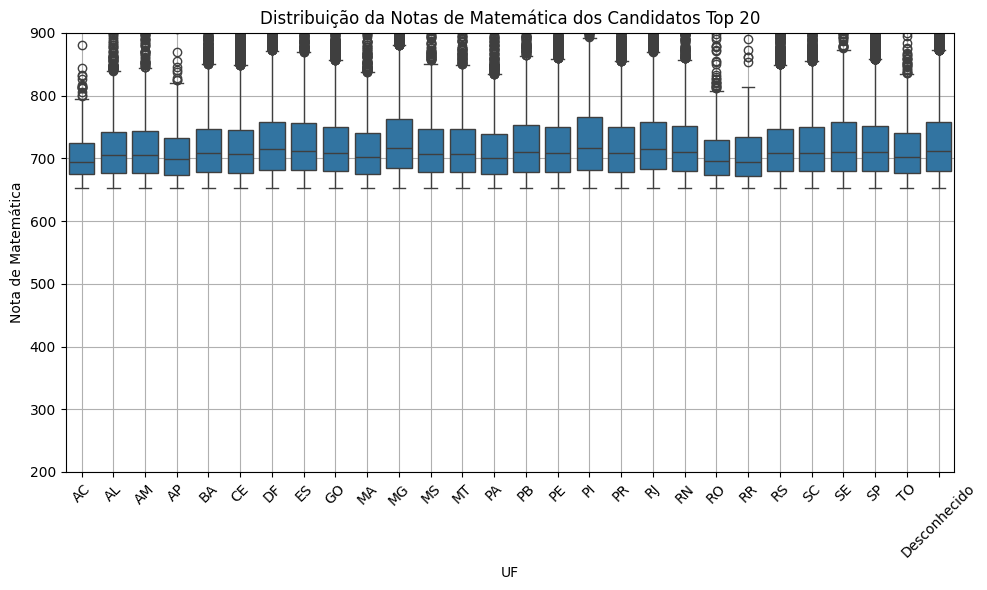

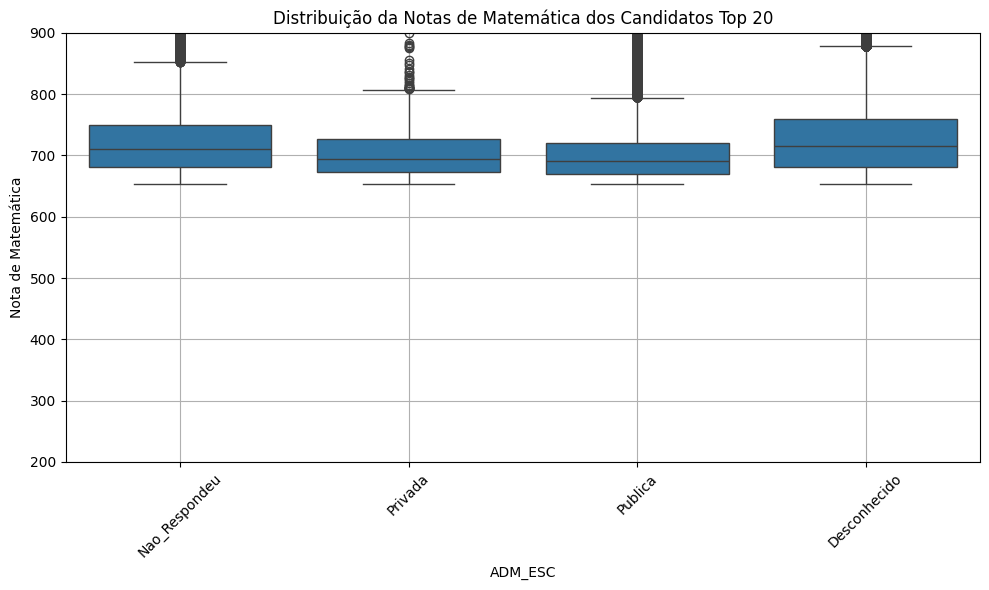

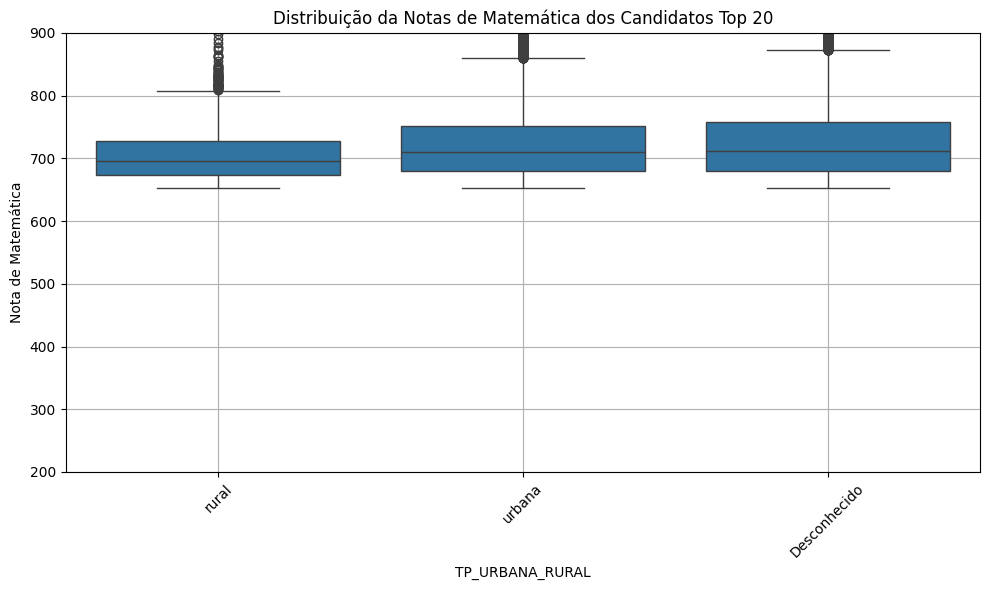

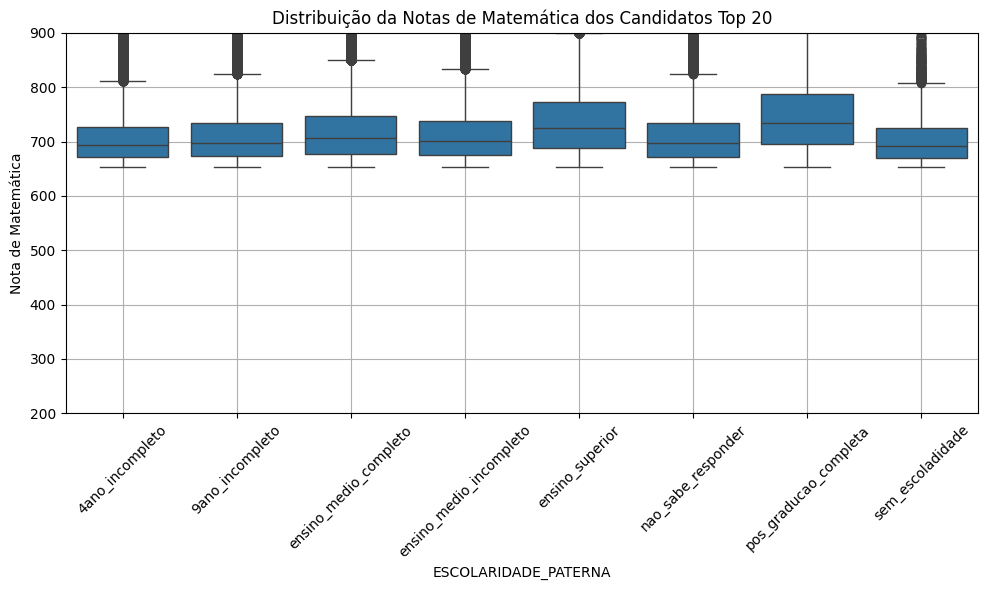

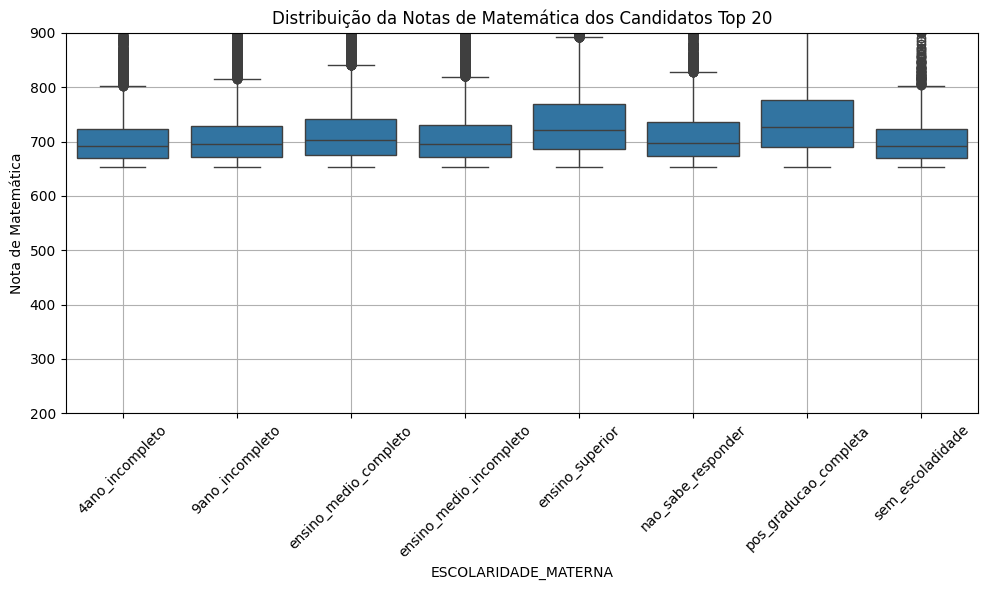

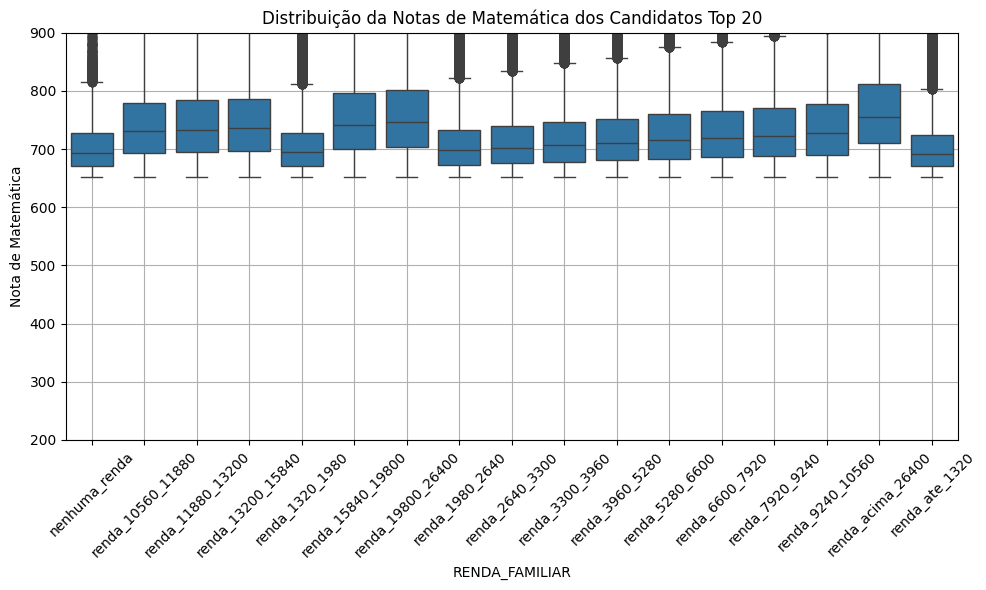

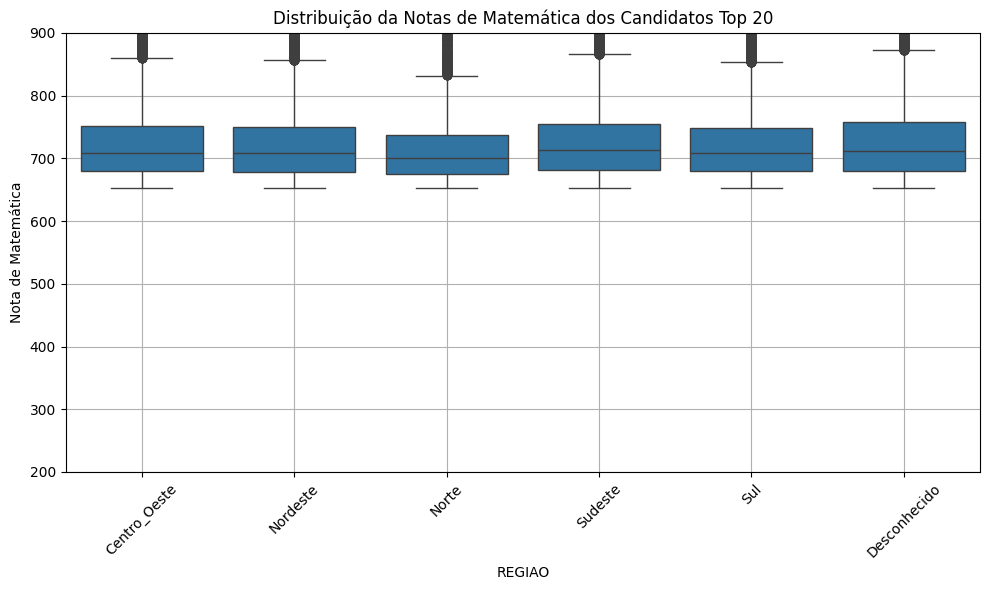

In [37]:
for cat in categoricas:    
    df_melt = top_20.melt(
        id_vars=cat,
        value_vars=['NOTA_MT'],
        var_name='Área',
        value_name='Nota'
    )

    # Um único gráfico com boxplots por REGIAO
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_melt, x=cat, y='Nota')

    plt.title(f'Distribuição da Notas de Matemática dos Candidatos Top 20')
    plt.ylabel('Nota de Matemática')
    plt.ylim(200, 900)
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

#### Correlação entre as variáveis socieconômicas e a renda familiar

In [38]:
colunas_corr=['ESCOLARIDADE_PATERNA',
       'ESCOLARIDADE_MATERNA', 'POSSUI_DIARISTA',
       'QTD_BANHEIROS', 'QTD_CARROS', 'QTD_TV_COLORIDA',
       'QTD_COMPUTADOR', 'ACESSO_INTERNET'
       ]

O teste qui-quadrado verificar se há associação estatística entre as variáveis, isto é, se a distribuição de uma variável depende da outra. Se o p-valor for menor que 0,05, então há associação entre as variáveis.

O coeficiente de V de Crammer, mede a força da associação entre duas variáveis categóricas (valores entre 0 e 1), onde 0 indica nenhuma associação e 1 indica associação perfeita.

In [39]:
dict_corr = {'variavel': [], 'p-valor': [], 'Qui2': [], 'V Cramer': []}

for cat in colunas_corr:
    # Cria tabela de contingência
    tabela_contingencia = pd.crosstab(presentes_df_enem_2023['RENDA_FAMILIAR'], presentes_df_enem_2023[cat])
    
    # Teste qui-quadrado
    chi2, p, dof, expected = stats.chi2_contingency(tabela_contingencia)
    
    # Cálculo do V de Cramer (forma mais precisa)
    n = tabela_contingencia.sum().sum()  # total de observações
    phi2 = chi2 / n
    r, k = tabela_contingencia.shape  # número de linhas e colunas
    cramer = np.sqrt(phi2 / min((k-1), (r-1)))
    
    # Armazena resultados
    dict_corr['variavel'].append(cat)
    dict_corr['p-valor'].append(p)
    dict_corr['Qui2'].append(chi2)
    dict_corr['V Cramer'].append(cramer)
# Cria DataFrame final
resultado_corr = (pd.DataFrame(dict_corr)
                 .sort_values(by='V Cramer', ascending=False)
                 .reset_index(drop=True))  # drop=True para evitar coluna extra

In [40]:
presentes_df_enem_2023.columns


Index(['INSCRICAO', 'FAIXA_ETARIA', 'SEXO', 'ESTADO_CIVIL', 'COR',
       'NACIONALIDADE', 'ST_CONCLUSAO', 'ANO_CONCLUSAO', 'MUNICIPIO', 'UF',
       'ADM_ESC', 'TP_URBANA_RURAL', 'TP_PRESENCA_CH', 'TP_PRESENCA_MT',
       'NOTA_CN', 'NOTA_CH', 'NOTA_LC', 'NOTA_MT', 'NOTA_COMP1_REDACAO',
       'NOTA_COMP2_REDACAO', 'NOTA_COMP3_REDACAO', 'NOTA_COMP4_REDACAO',
       'NOTA_COMP5_REDACAO', 'NOTA_REDACAO', 'ESCOLARIDADE_PATERNA',
       'ESCOLARIDADE_MATERNA', 'RENDA_FAMILIAR', 'POSSUI_DIARISTA',
       'QTD_BANHEIROS', 'QTD_CARROS', 'QTD_GELADEIRA', 'QTD_TV_COLORIDA',
       'QTD_COMPUTADOR', 'ACESSO_INTERNET', 'REGIAO', 'MEDIA', 'IS_TOP20'],
      dtype='object')

Dentre as características socieconômicas, todas as consideradas no trabalho estão associadas com a renda familiar e, portanto, reduziremos essas variáveis a apenas a que diz respeito a renda familiar e escolaridade paterna e materna.